# Explainable Value-Aware Customer Churn Prediction and Retention Prioritisation



## 1. Introduction

### 1.1 Background and rationale

Customer churn is the termination of a customer's relationship with a service provider. In subscription-based telecommunications, churn directly reduces recurring revenue and can weaken the return on customer-acquisition expenditure. A proactive retention strategy therefore requires two linked capabilities: identifying customers whose probability of churn is elevated and determining which of those customers should be prioritised when retention resources are limited. Recent reviews show that ensemble learning is prominent in churn prediction, but also identify persistent weaknesses concerning class imbalance, interpretability, concept drift, and limited use of business-oriented evaluation . Explainable machine learning is particularly important because a prediction is more actionable when decision-makers can understand the customer and service characteristics associated with it.

This project addresses these issues through a reproducible, leakage-controlled comparison of statistical, ensemble, boosting, and neural-network classifiers. It evaluates targeted imbalance treatments, explains the selected model with SHAP, combines predicted churn probability with IBM's supplied customer lifetime value (CLTV), and conducts an exploratory time-to-event analysis. Deep sequential architectures are not used because the available data are a single tabular snapshot rather than a longitudinal interaction sequence; such architectures are better motivated when repeated or multimedia observations are available.


### 1.2 Problem statement

The telecommunications provider needs to identify customers at elevated risk of leaving before attrition occurs. This is difficult because churners form the minority class, the cost of missing a churner differs from the cost of contacting a loyal customer, and highly predictive models may be computationally expensive or difficult to explain. A model selected only by accuracy may favour the majority non-churn class, while a model selected without considering customer value may allocate retention incentives to low-value cases. The analytical problem is therefore to develop a model that ranks churn risk reliably, remains interpretable, and can support economically meaningful prioritisation without using information that would be unavailable at prediction time.




### 1.3 Research and business questions

**Research questions**

- **RQ1:** Which candidate classifier provides the strongest cross-validated churn ranking, measured primarily by precision–recall area under the curve (PR-AUC)?
- **RQ2:** How do class weighting and SMOTE-NC change discrimination, precision, recall, F1, calibration, and computational cost relative to the original class distribution?
- **RQ3:** Which demographic, service, contract, and billing characteristics have the strongest statistical and model-based associations with churn?
- **RQ4:** Can predicted churn probability and supplied CLTV be combined to create an interpretable retention-priority framework?
- **RQ5:** How does estimated customer retention vary by contract type, and which selected covariates are associated with the observed churn hazard?

**Business questions**

- Which customers should be contacted first?
- Which customer groups exhibit the highest observed churn rates?
- What precision–recall trade-off is acceptable for a retention campaign?
- Does the small predictive gain of a complex model justify its additional time, size, and interpretability cost?
- Which high-value customers require immediate intervention, loyalty monitoring, or routine management?


### 1.4 Analytical scope and notebook structure

The notebook treats churn prediction as the primary supervised-learning task. IBM's existing **CLTV** field is not re-modelled; it is used only after prediction as a business-prioritisation variable. Survival analysis is explicitly exploratory because the file is a cross-sectional customer snapshot rather than a prospectively observed cohort. The workflow proceeds from data audit and EDA to statistical testing, leakage-safe model comparison, focused imbalance evaluation, holdout assessment, SHAP interpretation, value-aware segmentation, and exploratory survival modelling.

The literature motivates comparing interpretable baselines with ensemble learners, examining imbalance explicitly, reporting several metrics rather than accuracy alone, evaluating computational cost, and using explanation methods to translate predictions into decisions.


In [ ]:
%pip install -q imbalanced-learn xgboost lightgbm catboost shap lifelines statsmodels

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.0 MB/s eta 0:00:00


In [ ]:
import json
import os
import platform
import random
import time
import warnings
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.base import BaseEstimator, clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import(
    StratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [ ]:
# Reproducibility and experiment controls
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
FIGURE_DPI = 500
MODEL_N_JOBS = -1

FAST_MODE = False
RESUME_CV = True
MI_PERCENTILE = 85

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print({
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_splits": N_SPLITS,
    "fast_mode": FAST_MODE,
    "mi_percentile": MI_PERCENTILE,
})

{'random_state': 42, 'test_size': 0.2, 'cv_splits': 5, 'fast_mode': False, 'mi_percentile': 85}


### Reproducibility protocol

A fixed random seed of 42, a stratified 80:20 holdout split, and five-fold stratified cross-validation are used to make comparisons repeatable. The untouched test set is reserved for final evaluation after model and imbalance-treatment selection. Mutual-information feature selection is fitted inside each pipeline and therefore inside each training fold, reducing optimistic bias from information leakage. `FAST_MODE=False` records the full experiment rather than a reduced demonstration run.


## 2. Data Import, Audit, and Preparation


In [ ]:
from google.colab import drive, files

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/IBM_Telco_Customer_Churn")
DATA_DIR = PROJECT_DIR / "dataset"
OUTPUT_ROOT = PROJECT_DIR / "outputs"

OUTPUT_DIRS = {
    "processed" : OUTPUT_ROOT / "processed",
    "models" : OUTPUT_ROOT / "models",
    "results" : OUTPUT_ROOT / "results",
    "figures" : OUTPUT_ROOT / "figures"
}

for folder in [PROJECT_DIR, DATA_DIR, *OUTPUT_DIRS.values()]:
  folder.mkdir(parents=True, exist_ok=True)

DATA_FILENAME = "IBM_Telco_customer_churn_IBM_dataset.csv"
DATA_PATH = DATA_DIR / DATA_FILENAME

if not DATA_PATH.exists():
  print(f"Dataset not found at: {DATA_PATH}")
  uploaded = files.upload()
  uploaded_name, uploaded_bytes = next(iter(uploaded.items()))
  DATA_PATH.write_bytes(uploaded_bytes)
  print(f"Saved {uploaded_name} to {DATA_PATH}")

print("Project directory: ", PROJECT_DIR)
print("Dataset path: ", DATA_PATH)
for name, path in OUTPUT_DIRS.items():
  print(f"{name:>0}: {path}")

Mounted at /content/drive
Project directory:  /content/drive/MyDrive/IBM_Telco_Customer_Churn
Dataset path:  /content/drive/MyDrive/IBM_Telco_Customer_Churn/dataset/IBM_Telco_customer_churn_IBM_dataset.csv
processed: /content/drive/MyDrive/IBM_Telco_Customer_Churn/outputs/processed
models: /content/drive/MyDrive/IBM_Telco_Customer_Churn/outputs/models
results: /content/drive/MyDrive/IBM_Telco_Customer_Churn/outputs/results
figures: /content/drive/MyDrive/IBM_Telco_Customer_Churn/outputs/figures


### Data storage and output management

Google Drive is used as persistent storage for the source dataset, analysis-ready data, fitted pipelines, result tables, and figures. Creating the directory structure programmatically supports reproducibility and prevents results from being scattered across temporary Colab storage. If the dataset is absent, the notebook requests a one-time upload and then saves it to the project directory.


In [ ]:
def save_and_show(path, dpi=FIGURE_DPI):
  path = Path(path)
  path.parent.mkdir(parents=True, exist_ok=True)
  plt.tight_layout()
  plt.savefig(path, dpi=dpi, bbox_inches="tight")
  plt.show()
  plt.close()

raw_df = pd.read_csv(DATA_PATH)
print("Shape:", raw_df.shape)
display(raw_df.head())

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.9641,-118.2728,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.0593,-118.3074,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.0480,-118.2940,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.6500,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.0621,-118.3157,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8000,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.0392,-118.2663,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.7000,5036.3,Yes,1,89,5340,Competitor had better devices


### 2.1 Data description

The IBM Telco Customer Churn dataset contains **7,043 customer records and 33 variables**. Each row represents one fictional telecommunications customer observed at a snapshot in time. The fields cover the following information domains:

| Domain | Variables | Analytical role |
|---|---|---|
| Identifier and geography | CustomerID, Count, Country, State, City, Zip Code, Lat Long, Latitude, Longitude | Identification, audit, and limited geographic context |
| Demographics | Gender, Senior Citizen, Partner, Dependents | Customer characteristics |
| Services | Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies | Subscription configuration |
| Account and billing | Tenure Months, Contract, Paperless Billing, Payment Method, Monthly Charges, Total Charges | Relationship length and commercial arrangement |
| Outcome and business fields | Churn Label, Churn Value, Churn Score, CLTV, Churn Reason | Target validation, outcome description, or post-model prioritisation |

`Churn Value` is the binary target: 1 denotes churn and 0 denotes non-churn. `Churn Label` is its text equivalent and is used only for consistency checking. `Churn Score` and `Churn Reason` are not valid pre-churn predictors because they encode model-generated or post-outcome information. The supplied `CLTV` is excluded from churn-model training and introduced later for value-aware prioritisation.


In [ ]:
audit = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_n": raw_df.isna().sum(),
    "missing_pct": raw_df.isna().mean() * 100,
    "unique_n": raw_df.nunique(dropna=False),
}).sort_values(["missing_n", "unique_n"], ascending=[False, True])

print("Duplicate rows: ", raw_df.duplicated().sum())
print("Duplicate CustomerIDs:", raw_df["CustomerID"].duplicated().sum())
display(audit)
audit.to_csv(OUTPUT_DIRS["results"] / "data_audit.csv")

Duplicate rows:  0
Duplicate CustomerIDs: 0


,dtype,missing_n,missing_pct,unique_n
Churn Reason,object,5174,73.4630,21
Count,int64,0,0.0000,1
Country,object,0,0.0000,1
State,object,0,0.0000,1
Gender,object,0,0.0000,2
Senior Citizen,object,0,0.0000,2
Partner,object,0,0.0000,2
Dependents,object,0,0.0000,2
Phone Service,object,0,0.0000,2
Paperless Billing,object,0,0.0000,2


### Data-quality assessment

The audit identifies no duplicated rows and no duplicated customer identifiers, supporting the assumption that the unit of analysis is one customer. `Count`, `Country`, and `State` each have one unique value and consequently provide no discriminatory information. `City`, `Zip Code`, and `Lat Long` have high cardinality or duplicate the information in latitude and longitude and are excluded to reduce sparsity and overfitting risk.

`Churn Reason` is missing for exactly 5,174 records (73.46%), which corresponds to the non-churn population; this is structural rather than random missingness because a non-churner has no churn reason. `Total Charges` initially appears complete because blank strings are stored as text. Its conversion to numeric in the next step reveals the true missing values.


In [ ]:
df = raw_df.copy()

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Churn Value"] = pd.to_numeric(df["Churn Value"], errors="raise").astype(int)

if not set(df["Churn Value"].dropna().unique()).issubset({0, 1}):
  raise ValueError("Churn Value must contain only 0 and 1")

label_as_binary = (
    df["Churn Label"].astype("string").str.strip().str.lower()
    .map({"yes": 1, "no": 0})
)

if label_as_binary.isna().any() or not label_as_binary.eq(df["Churn Value"]).all():
  raise ValueError("Churn Label and Churn Value are inconsistent")


print(df["Churn Value"].value_counts().sort_index())
print("Missing Total Charges: ", df["Total Charges"].isna().sum())
display(df.loc[df["Total Charges"].isna(),
               ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges"]])

Churn Value
0    5174
1    1869
Name: count, dtype: int64
Missing Total Charges:  11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.5500,NaN
2438,3115-CZMZD,0,20.2500,NaN
2568,5709-LVOEQ,0,80.8500,NaN
2667,4367-NUYAO,0,25.7500,NaN
2856,1371-DWPAZ,0,56.0500,NaN
4331,7644-OMVMY,0,19.8500,NaN
4687,3213-VVOLG,0,25.3500,NaN
5104,2520-SGTTA,0,20.0000,NaN
5719,2923-ARZLG,0,19.7000,NaN
6772,4075-WKNIU,0,73.3500,NaN


### Target validation and missing-value treatment

`Churn Label` maps perfectly from *Yes/No* to `Churn Value` 1/0, confirming target consistency. Converting `Total Charges` to numeric produces 11 missing values, all belonging to customers with zero months of tenure. These blanks are substantively plausible for newly registered customers with no accumulated billing history. They are not filled globally at this stage: median imputation is learned later inside each training fold, which avoids allowing validation or test information to influence preprocessing.


In [ ]:
TARGET_COL = "Churn Value"

RAW_NUMERICAL_COLS = [
    "Latitude", "Longitude", "Tenure Months",
    "Monthly Charges", "Total Charges"
]

RAW_CATEGORICAL_COLS = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method"
]

EXCLUDED_COLUMNS = [
    "CustomerID", "Count", "Country", "State", "City", "Zip Code",
    "Lat Long", "Churn Label", "Churn Score", "CLTV", "Churn Reason"
]

print("Numerical EDA columns:", RAW_NUMERICAL_COLS)
print("Categorical EDA columns:", RAW_CATEGORICAL_COLS)
print("Excluded columns:", EXCLUDED_COLUMNS)

Numerical EDA columns: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges']
Categorical EDA columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Excluded columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']


### Leakage prevention and variable eligibility

The modelling set retains five numerical and sixteen categorical source predictors. Exclusion decisions are made before model fitting:

| Excluded field(s) | Reason |
|---|---|
| CustomerID | Unique identifier with no generalisable behavioural meaning |
| Count, Country, State | Constant fields |
| City, Zip Code, Lat Long | High-cardinality or redundant geographic representations |
| Churn Label | Exact duplicate of the binary target |
| Churn Score | Existing model-generated assessment; direct leakage risk |
| Churn Reason | Known only after churn and structurally missing for non-churners |
| CLTV | Supplied value measure reserved for post-prediction prioritisation |

This distinction is essential: a high score obtained with post-outcome information would not represent a deployable pre-churn prediction system.


In [ ]:
ADD_ON_COLUMNS = [
    "Online Security", "Online Backup", "Device Protection", "Tech Support"
]
STREAMING_COLUMNS = ["Streaming TV", "Streaming Movies"]


def add_engineered_features(frame):
    '''Create deterministic, target-independent customer-service features.'''
    out = frame.copy()

    out["Number of Add-on Services"] = out[ADD_ON_COLUMNS].eq("Yes").sum(axis=1)
    out["Number of Streaming Services"] = out[STREAMING_COLUMNS].eq("Yes").sum(axis=1)

    base_services = (
        out["Phone Service"].eq("Yes").astype(int)
        + out["Internet Service"].ne("No").astype(int)
        + out["Number of Add-on Services"]
        + out["Number of Streaming Services"]
    )
    out["Monthly Charge per Service"] = (
        out["Monthly Charges"] / base_services.clip(lower=1)
    )

    out["Tenure Group"] = pd.cut(
        out["Tenure Months"],
        bins=[-0.1, 12, 24, 48, 60, np.inf],
        labels=["0–12", "13–24", "25–48", "49–60", "61+"],
        include_lowest=True,
    ).astype("string")

    return out


df_model = add_engineered_features(df)

NUMERICAL_COLS = RAW_NUMERICAL_COLS + [
    "Number of Add-on Services",
    "Number of Streaming Services",
    "Monthly Charge per Service",
]

CATEGORICAL_COLS = RAW_CATEGORICAL_COLS + ["Tenure Group"]

FEATURE_COLS = NUMERICAL_COLS + CATEGORICAL_COLS

print("Model features:", len(FEATURE_COLS))
print("Numerical:", len(NUMERICAL_COLS))
print("Categorical:", len(CATEGORICAL_COLS))

# Save a reproducible analysis-ready version to Drive.
processed_path = OUTPUT_DIRS["processed"] / "telco_churn_analysis_ready.csv"
df_model.to_csv(processed_path, index=False)
print("Saved:", processed_path)

Model features: 25
Numerical: 8
Categorical: 17
Saved: /content/drive/MyDrive/IBM_Telco_Customer_Churn/outputs/processed/telco_churn_analysis_ready.csv


### Feature-engineering rationale

Four deterministic, target-independent variables are created. Counts of add-on and streaming services summarise subscription breadth; monthly charge per service approximates price intensity; and tenure group permits non-linear differences across the customer life cycle. The resulting design contains **25 predictors**—8 numerical and 17 categorical—before one-hot expansion. Because these variables are derived without consulting churn labels, they can be computed for future customers at inference time.


## 3. Exploratory Data Analysis


No Churn: 5174 (73.46%)
Churn: 1869 (26.54%)


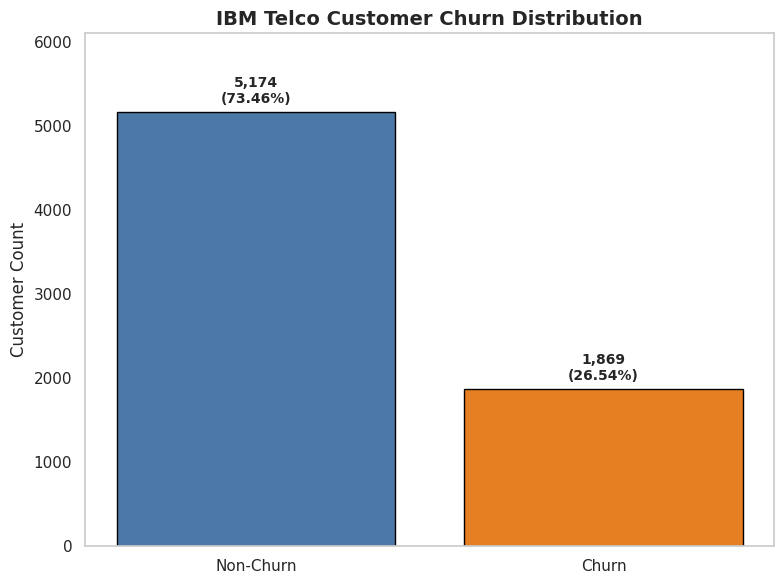

In [ ]:
#Target distribution

target_counts = df_model[TARGET_COL].value_counts().reindex([0, 1])
target_pct = target_counts / len(df_model) * 100.00

print(f"No Churn: {target_counts.loc[0]} ({target_pct.loc[0]:.2f}%)")
print(f"Churn: {target_counts.loc[1]} ({target_pct.loc[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    ["Non-Churn", "Churn"],
    target_counts.values,
    color=["#4C78A8", "#E67E22"],
    edgecolor="black"
)

ax.bar_label(
    bars,
    labels=[f"{target_counts.loc[i]:,}\n({target_pct.loc[i]:.2f}%)" for i in [0, 1]],
    padding=4,
    fontweight="bold",
    fontsize=10
)

ax.set_title("IBM Telco Customer Churn Distribution", fontweight="bold", fontsize=14)
ax.set_ylabel("Customer Count")
ax.set_ylim(0, target_counts.max() * 1.18)
ax.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "01_target_distribution.png")

### Target-distribution insight

The dataset contains **5,174 non-churners (73.46%)** and **1,869 churners (26.54%)**, equivalent to an approximately **2.77:1** majority-to-minority ratio. This is a meaningful but not extreme imbalance. It explains why the dummy majority classifier later achieves 73.46% accuracy while identifying no churners. Consequently, accuracy is not used as the primary selection criterion; PR-AUC, recall, precision, F1, balanced accuracy, and calibration are reported alongside it.


,count,mean,std,min,25%,50%,75%,max,missing_n,skewness
Latitude,"7,043.0000",36.2824,2.4557,32.5558,34.0309,36.3918,38.2249,41.9621,0,0.3039
Longitude,"7,043.0000",-119.7989,2.1579,-124.3014,-121.8154,-119.7309,-118.0432,-114.1929,0,-0.0408
Tenure Months,"7,043.0000",32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000,0,0.2395
Monthly Charges,"7,043.0000",64.7617,30.0900,18.2500,35.5000,70.3500,89.8500,118.7500,0,-0.2205
Total Charges,"7,032.0000","2,283.3004","2,266.7714",18.8000,401.4500,"1,397.4750","3,794.7375","8,684.8000",11,0.9616


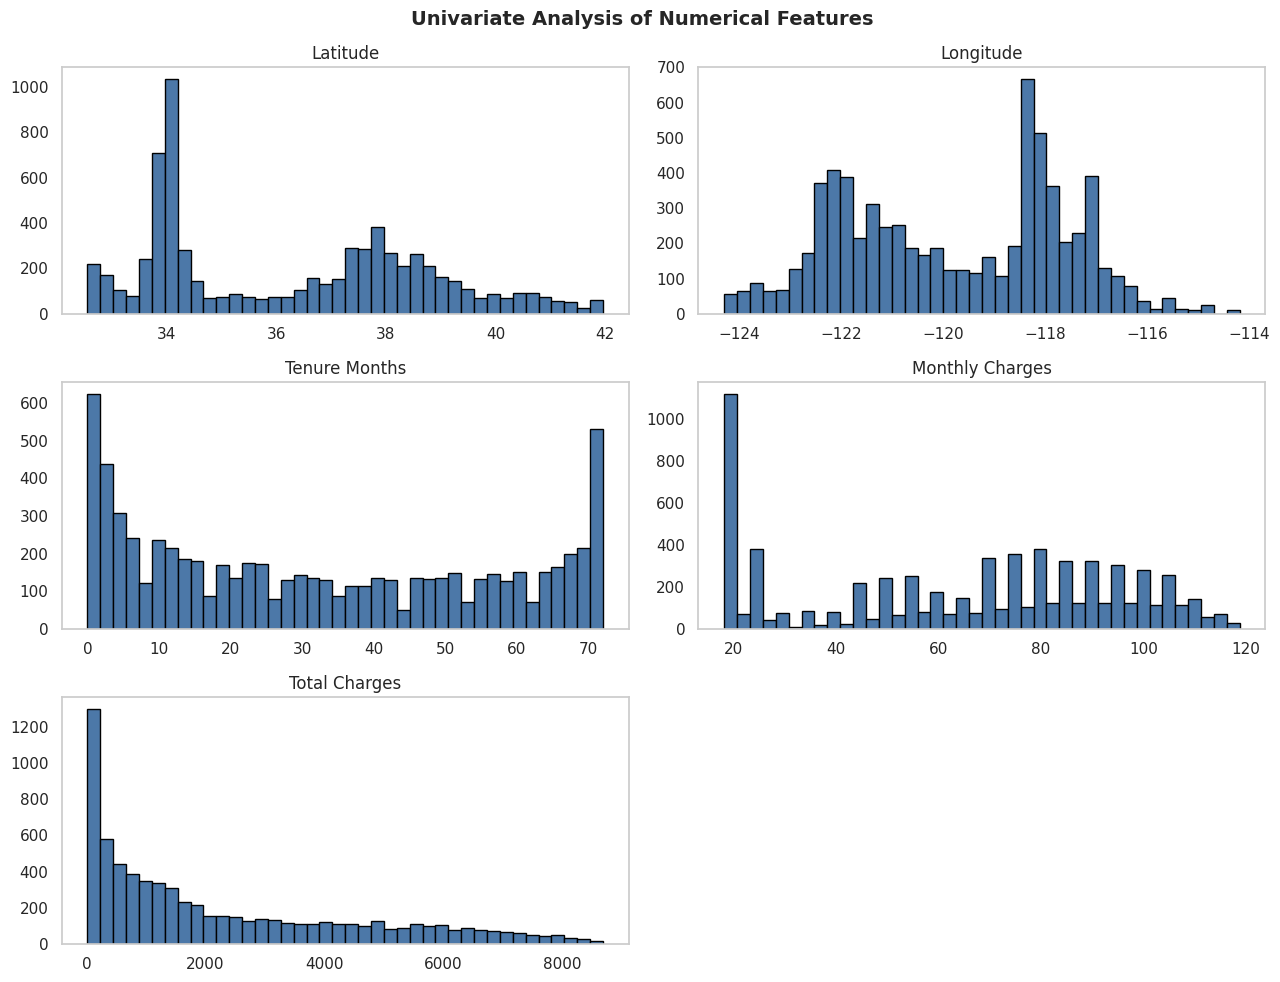

In [ ]:
#Univariate Analysis of Numerical Features

numerical_summary = df[RAW_NUMERICAL_COLS].describe().T
numerical_summary["missing_n"] = df_model[RAW_NUMERICAL_COLS].isna().sum()
numerical_summary["skewness"] = df_model[RAW_NUMERICAL_COLS].skew(numeric_only=True)
display(numerical_summary)
numerical_summary.to_csv(OUTPUT_DIRS["results"] / "numerical_summary.csv")

axes = df_model[RAW_NUMERICAL_COLS].hist(
    bins=40,
    figsize=(13, 10),
    color="#4C78A8",
    edgecolor="black",
    grid=False
)

plt.suptitle("Univariate Analysis of Numerical Features", fontsize=14, fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "02_numerical_distributiion.png")

### Numerical-distribution insight

`Total Charges` is the most asymmetric variable (skewness = 0.962), with a long right tail produced by a smaller group of long-tenure or high-spending customers. Its median (1,397.48) is substantially below its mean (2,283.30). `Tenure Months` is mildly right-skewed (0.240), whereas `Monthly Charges` is mildly left-skewed (-0.221). Latitude and longitude are approximately symmetric, although their interpretation is limited to the geography represented in this dataset. The use of median imputation and standardisation inside the pipeline reduces sensitivity to skew and scale without applying a transformation that could obscure interpretation.


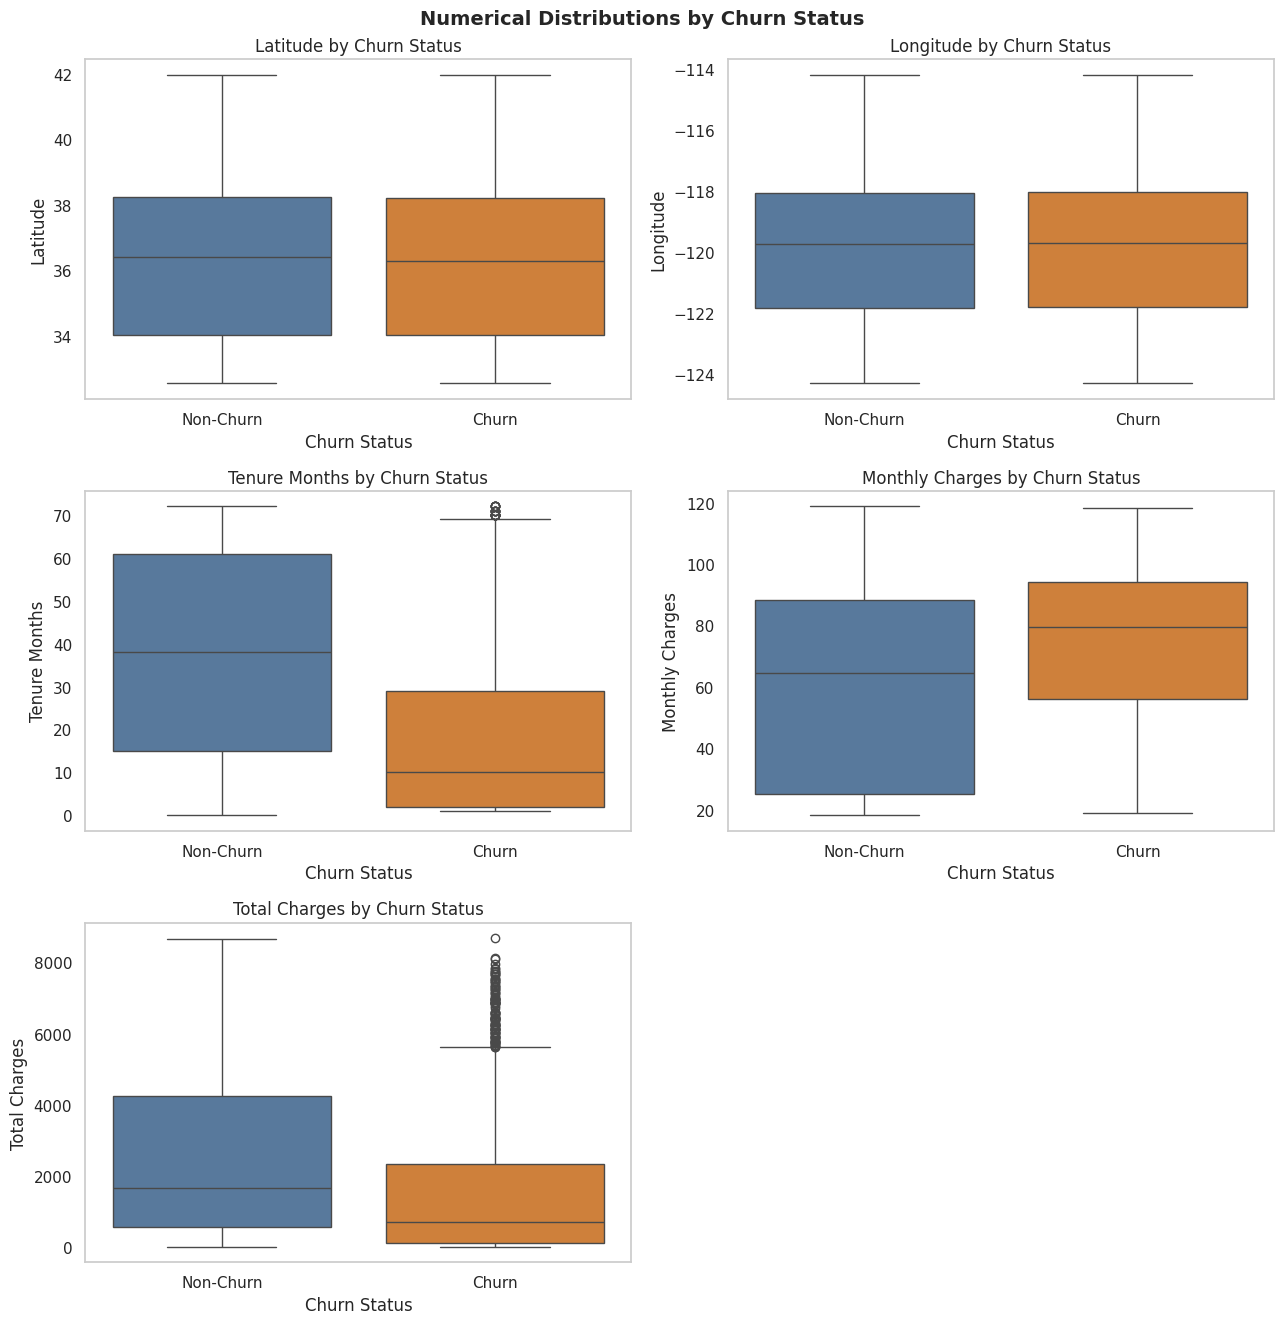

In [ ]:
# Numerical distributions by churn status
n_cols = 2
n_rows = -(-len(RAW_NUMERICAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(RAW_NUMERICAL_COLS):
  sns.boxplot(
      data=df_model,
      x=TARGET_COL,
      y=col,
      ax=axes[i],
      hue=TARGET_COL, palette={0: "#4C78A8", 1: "#E67E22"},
      legend=False
  )

  axes[i].set_title(f"{col} by Churn Status")
  axes[i].set_xlabel("Churn Status")
  axes[i].set_xticks([0,1], ["Non-Churn", "Churn"])
  axes[i].grid(False)

for j in range(len(RAW_NUMERICAL_COLS), len(axes)):
  fig.delaxes(axes[j])

plt.suptitle("Numerical Distributions by Churn Status", fontsize=14, fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "03_numerical_by_churn.png")

### Numerical differences by churn status

The largest visual separations concern tenure, accumulated charges, and monthly charges. Churners have a median tenure of **10 months**, compared with **38 months** among non-churners, and a lower median total charge (**703.55** versus **1,683.60**). In contrast, their median monthly charge is higher (**79.65** versus **64.43**). The geographic distributions overlap closely. These plots suggest that churn is concentrated among relatively new customers facing higher recurring charges, while lower total charges largely reflect their shorter exposure period. Formal group comparisons and effect sizes are reported in Section 4.


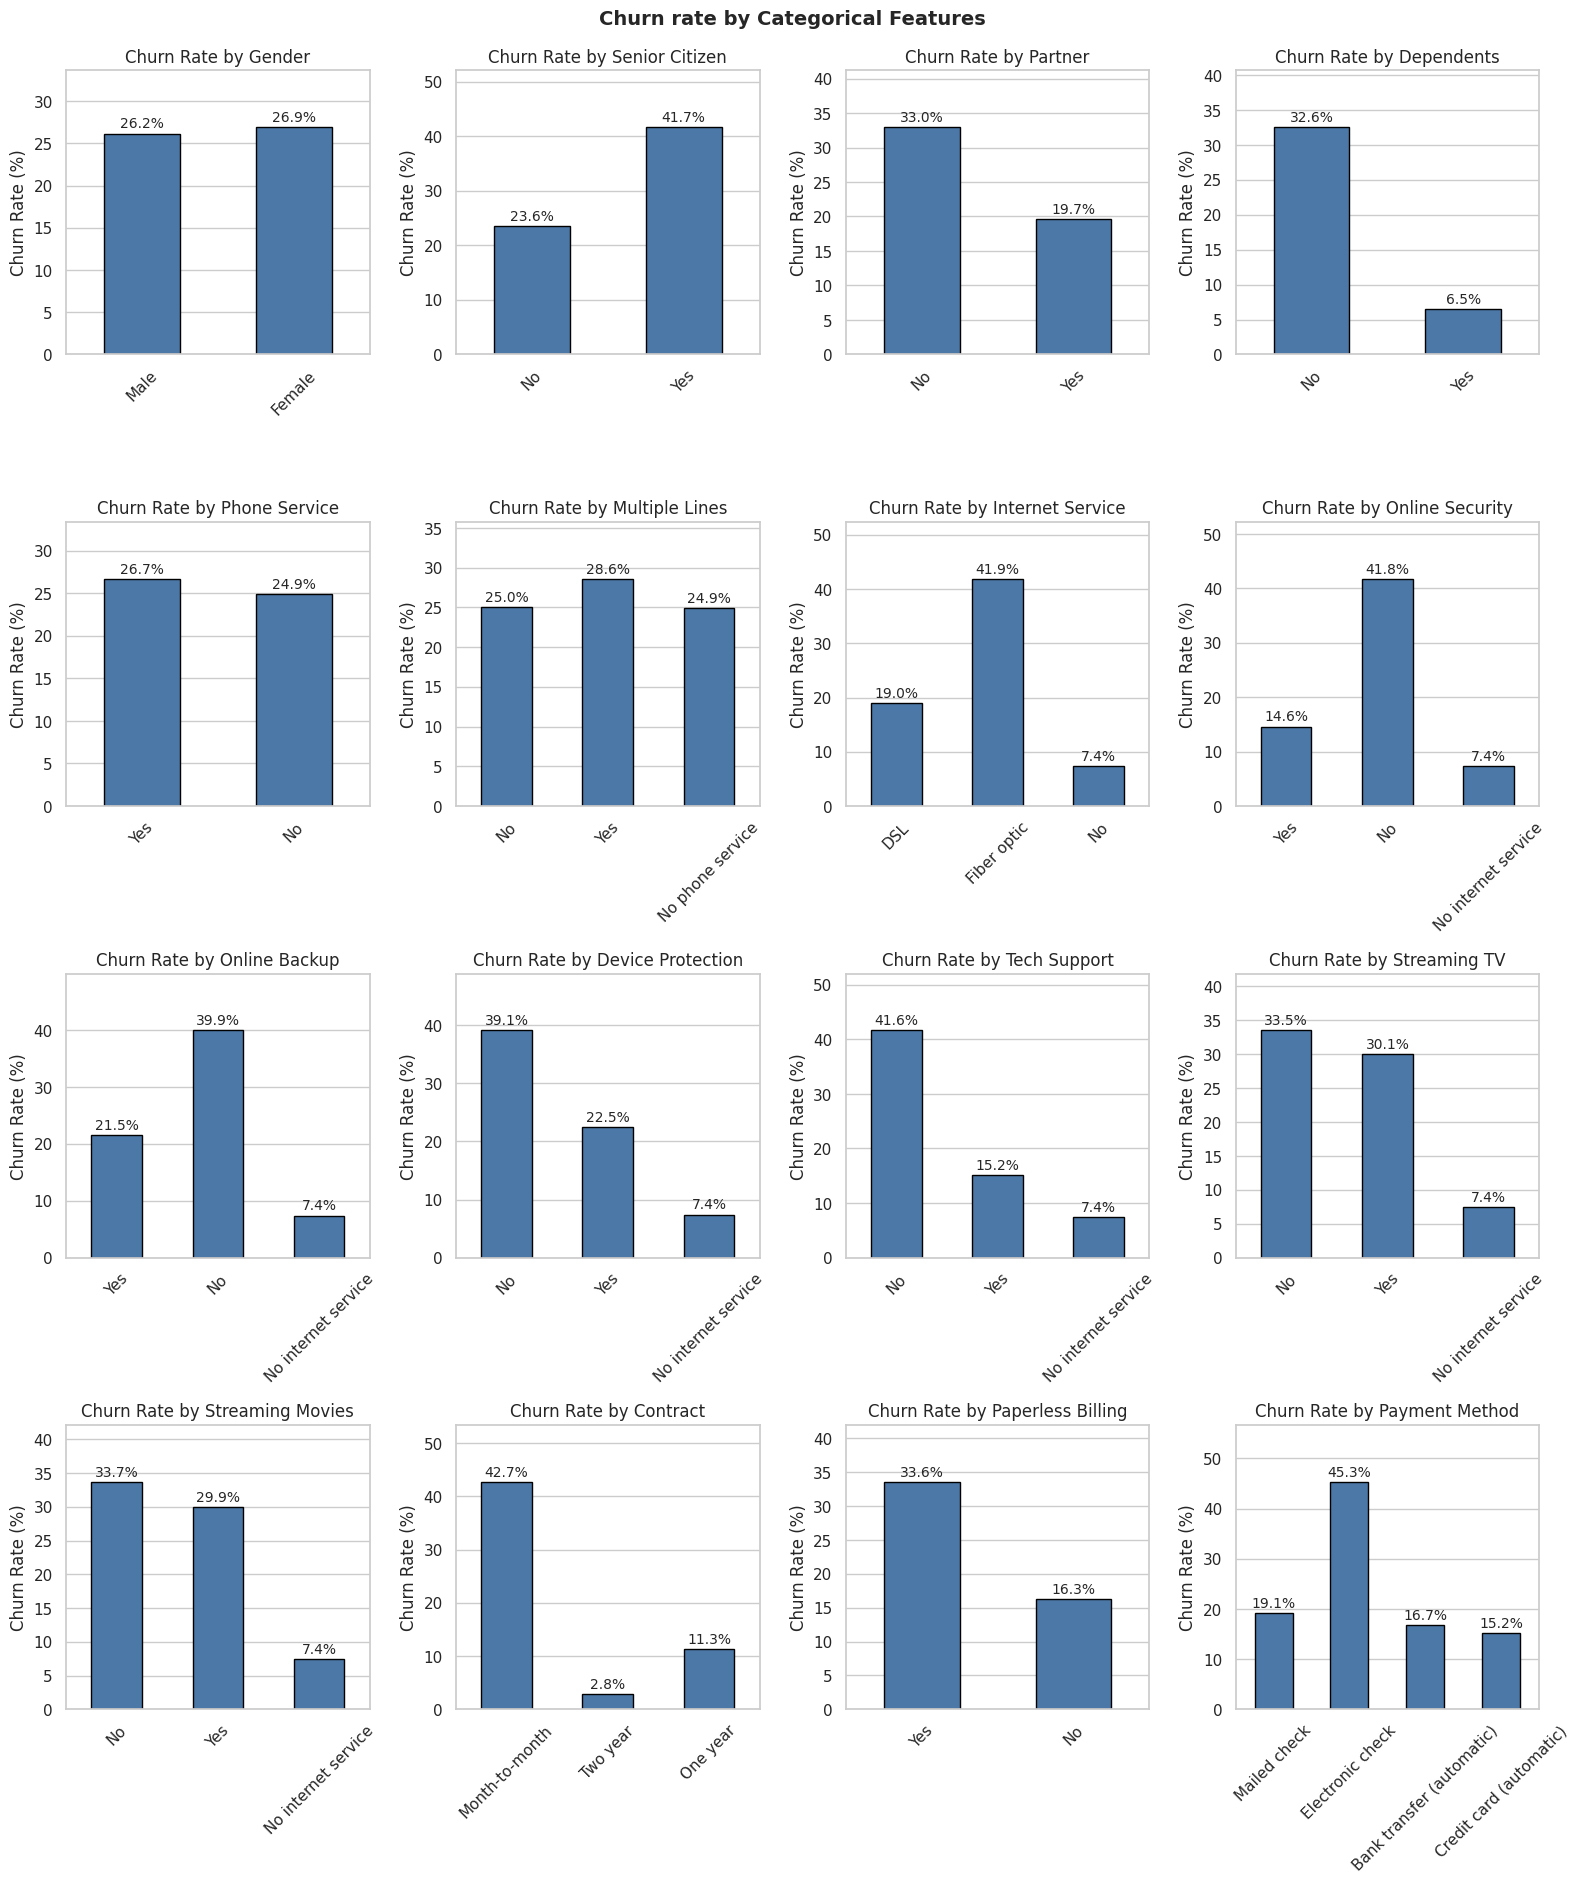

In [ ]:
# Categorical frequency plots
n_cols = 4
n_rows = -(-len(RAW_CATEGORICAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.8 * n_rows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(RAW_CATEGORICAL_COLS):
  churn_rate = (
      df_model.groupby(col, sort=False, observed=True)[TARGET_COL]
      .mean() * 100.00
  )

  bars = churn_rate.plot.bar(
      ax=axes[i],
      color="#4C78A8",
      edgecolor="black",
      linewidth=1
  )
  axes[i].set_title(f"Churn Rate by {col}")
  axes[i].set_xlabel("")
  axes[i].set_ylabel("Churn Rate (%)")
  axes[i].tick_params(axis="x", rotation=45)
  axes[i].bar_label(
      bars.containers[0],
      labels=[f"{v:.1f}%" for v in churn_rate],
      padding=2,
      fontsize=10
  )
  axes[i].set_ylim(0, max(5, churn_rate.max() * 1.25))
  axes[i].xaxis.grid(False)

for j in range(len(RAW_CATEGORICAL_COLS), len(axes)):
  fig.delaxes(axes[j])

plt.suptitle("Churn rate by Categorical Features\n", fontsize=14, fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "05_categorical_churn_rate.png")


### Categorical churn-rate insight

The largest descriptive contrasts are commercial rather than demographic. Month-to-month customers have a **42.7%** churn rate, compared with **11.3%** for one-year and **2.8%** for two-year contracts. Churn is also elevated for fibre-optic customers (**41.9%**), electronic-check users (**45.3%**), customers without online security (**41.8%**) or technical support (**41.6%**), senior citizens (**41.7%**), and customers without dependents (**32.6%**). Gender and phone-service categories differ very little.

These are unadjusted group rates. They are useful for customer profiling but should not be interpreted causally: for example, the fibre-optic association may partly reflect correlated price, contract, or service characteristics. Retention action should therefore combine these patterns with multivariable predictions and domain knowledge.


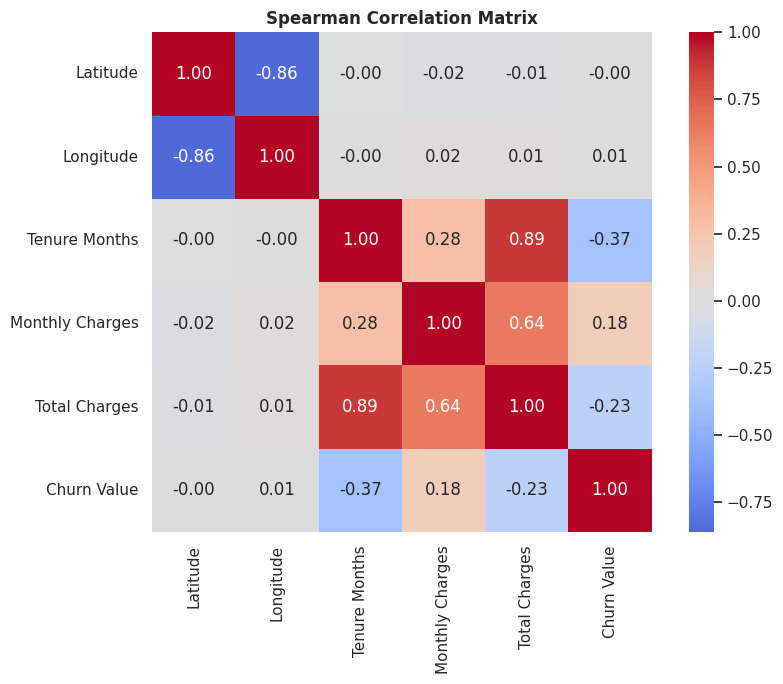

In [ ]:
# Spearman correlations for numerical features and binary target
corr_cols = RAW_NUMERICAL_COLS + [TARGET_COL]
corr = df_model[corr_cols].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Spearman Correlation Matrix", fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "06_spearman_correlation.png")

corr.to_csv(OUTPUT_DIRS["results"] / "spearman_correlation.csv")

### Correlation insight

Spearman correlation confirms that tenure has the strongest numerical relationship with churn (ρ = **-0.37**), followed by total charges (ρ = **-0.23**) and monthly charges (ρ = **0.18**). Total charges are strongly correlated with tenure (ρ = **0.89**) and moderately correlated with monthly charges (ρ = **0.64**), because accumulated billing is jointly determined by relationship length and recurring cost. Latitude and longitude are strongly inversely correlated (ρ = **-0.86**) due to the shape of the sampled geography but are essentially unrelated to churn. These dependencies motivate multivariable modelling and caution against reading any single association in isolation.


## 4. Statistical Analysis


### Statistical-testing framework

Mann–Whitney U tests compare numerical distributions without assuming normality; rank-biserial correlation quantifies effect magnitude. Chi-square tests examine categorical association, while bias-corrected Cramér's V measures its strength. Holm correction controls family-wise error for the five numerical tests, and Benjamini–Hochberg false-discovery-rate correction is used for the larger categorical family. Mutual information provides a complementary, model-free measure capable of capturing non-linear dependence. Statistical significance is interpreted together with effect size because the sample is large enough for small differences to become significant.


In [ ]:
# Mann-whitney U tests with rank-biserial effect sizes

mw_results = []

for col in RAW_NUMERICAL_COLS:
  values = pd.to_numeric(df_model[col], errors="coerce")
  group0 = values[df_model[TARGET_COL] == 0].dropna()
  group1 = values[df_model[TARGET_COL] == 1].dropna()

  result = mannwhitneyu(group0, group1, alternative="two-sided", method="auto")
  n0, n1 = len(group0), len(group1)

  rank_biserial = 1 - (2 * result.statistic) / (n0 * n1)

  mw_results.append({
      "Feature": col,
      "Non-Churn N": n0,
      "Churn N": n1,
      "Non-Churn Median": group0.median(),
      "Churn Median": group1.median(),
      "U-statistic": result.statistic,
      "p-value": result.pvalue,
      "Rank-Biserial r": rank_biserial,
  })

mw_df = pd.DataFrame(mw_results)
mw_df["Holm-adjusted p"] = multipletests(mw_df["p-value"], method="holm")[1]
mw_df["Significant (Holm < .05)"] = mw_df["Holm-adjusted p"] < 0.05
mw_df = mw_df.sort_values("Rank-Biserial r", key=lambda s: s.abs(), ascending=False)

display(mw_df)
mw_df.to_csv(OUTPUT_DIRS["results"] / "mann_whitney_results.csv", index=False)




,Feature,Non-Churn N,Churn N,Non-Churn Median,Churn Median,U-statistic,p-value,Rank-Biserial r,Holm-adjusted p,Significant (Holm < .05)
2,Tenure Months,5174,1869,38.0000,10.0000,"7,154,668.0000",0.0000,-0.4797,0.0000,True
4,Total Charges,5163,1869,"1,683.6000",703.5500,"6,288,982.0000",0.0000,-0.3035,0.0000,True
3,Monthly Charges,5174,1869,64.4250,79.6500,"3,667,080.5000",0.0000,0.2416,0.0000,True
1,Longitude,5174,1869,-119.7399,-119.7119,"4,798,626.5000",0.6283,0.0075,1.0000,False
0,Latitude,5174,1869,36.4144,36.2988,"4,840,613.5000",0.9417,-0.0011,1.0000,False


### Mann–Whitney U results

Tenure has the largest numerical effect (rank-biserial *r* = **-0.480**, Holm-adjusted *p* < .001), indicating substantially higher tenure among non-churners. Total charges show a moderate difference (*r* = **-0.304**, adjusted *p* < .001), while monthly charges show a smaller positive association with churn (*r* = **0.242**, adjusted *p* < .001). Latitude and longitude are non-significant after correction and have negligible effects (|*r*| < .01). The sign reflects the group ordering used in the calculation; practical interpretation should focus on the reported medians and absolute magnitude.


In [ ]:
def bias_corrected_cramers_v(table):
    '''Bias-corrected Cramér's V for a contingency table.'''
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    rows, cols = table.shape
    phi2_corr = max(0, phi2 - ((cols - 1) * (rows - 1)) / max(n - 1, 1))
    rows_corr = rows - ((rows - 1) ** 2) / max(n - 1, 1)
    cols_corr = cols - ((cols - 1) ** 2) / max(n - 1, 1)
    denominator = min(cols_corr - 1, rows_corr - 1)
    return np.sqrt(phi2_corr / denominator) if denominator > 0 else 0.0


chi_results = []

for col in RAW_CATEGORICAL_COLS:
    table = pd.crosstab(df_model[col], df_model[TARGET_COL], dropna=False)
    chi2, p, dof, _ = chi2_contingency(table)
    chi_results.append({
        "Feature": col,
        "Chi-square": chi2,
        "Degrees of Freedom": dof,
        "p-value": p,
        "Cramer's V": bias_corrected_cramers_v(table),
    })

chi_df = pd.DataFrame(chi_results)
chi_df["FDR-adjusted p"] = multipletests(chi_df["p-value"], method="fdr_bh")[1]
chi_df["Significant (FDR < .05)"] = chi_df["FDR-adjusted p"] < 0.05
chi_df = chi_df.sort_values("Cramer's V", ascending=False)

display(chi_df)
chi_df.to_csv(OUTPUT_DIRS["results"] / "chi_square_cramers_v_results.csv", index=False)

,Feature,Chi-square,Degrees of Freedom,p-value,Cramer's V,FDR-adjusted p,Significant (FDR < .05)
13,Contract,"1,184.5966",2,0.0000,0.4098,0.0000,True
7,Online Security,849.9990,2,0.0000,0.3470,0.0000,True
10,Tech Support,828.1971,2,0.0000,0.3425,0.0000,True
6,Internet Service,732.3096,2,0.0000,0.3220,0.0000,True
15,Payment Method,648.1423,3,0.0000,0.3027,0.0000,True
8,Online Backup,601.8128,2,0.0000,0.2919,0.0000,True
9,Device Protection,558.4194,2,0.0000,0.2811,0.0000,True
3,Dependents,433.7344,1,0.0000,0.2479,0.0000,True
12,Streaming Movies,375.6615,2,0.0000,0.2304,0.0000,True
11,Streaming TV,374.2039,2,0.0000,0.2299,0.0000,True


### Chi-square and Cramér's V results

Contract has the strongest categorical association with churn (Cramér's V = **0.410**), followed by online security (**0.347**), technical support (**0.343**), internet service (**0.322**), and payment method (**0.303**). These findings are consistent with the descriptive churn-rate plots and identify relationship commitment, service protection, and billing behaviour as central customer-profile dimensions. Gender and phone service are not significant, while multiple lines is statistically significant but practically negligible (V = **0.036**). This contrast illustrates why effect sizes are more informative than *p*-values alone.


,Feature,Mutual Information
0,Contract,0.0985
1,Monthly Charge per Service,0.0750
2,Tenure Months,0.0737
3,Tenure Group,0.0649
4,Online Security,0.0647
5,Tech Support,0.0630
6,Internet Service,0.0556
7,Online Backup,0.0468
8,Total Charges,0.0448
9,Payment Method,0.0445


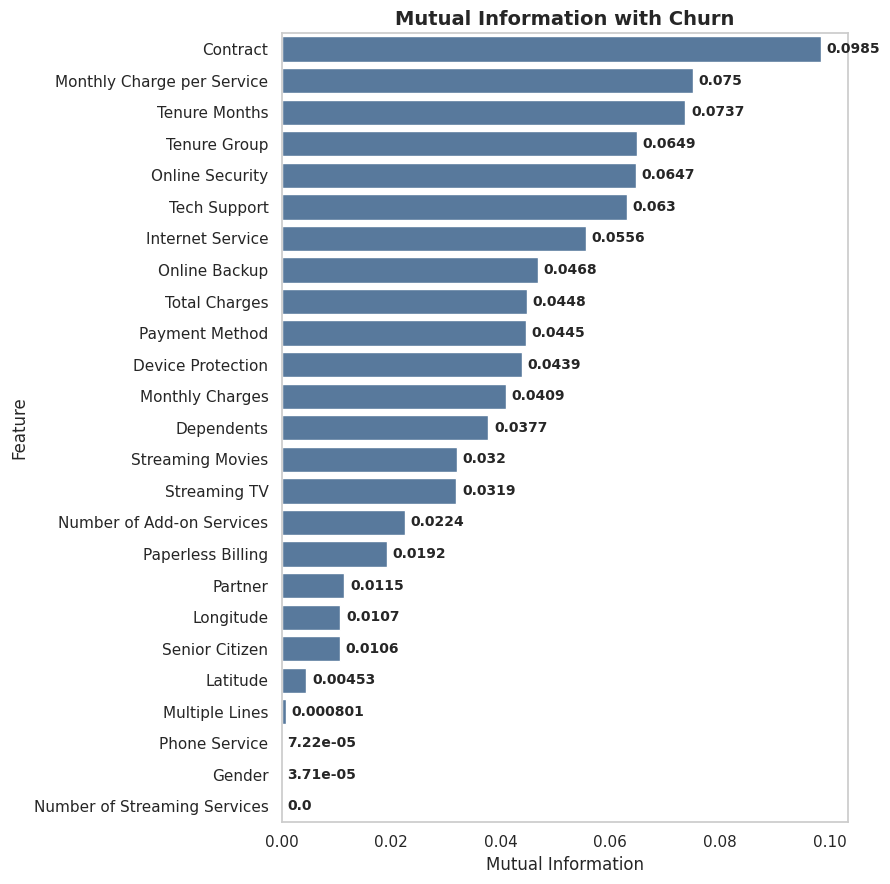

In [ ]:
# Mutual information for mixed numerical and categorical predictors
mi_num_pipe = SklearnPipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
mi_cat_pipe = SklearnPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    )),
])

mi_preprocessor = ColumnTransformer([
    ("num", mi_num_pipe, NUMERICAL_COLS),
    ("cat", mi_cat_pipe, CATEGORICAL_COLS),
], verbose_feature_names_out=False)

X_mi = mi_preprocessor.fit_transform(df_model[FEATURE_COLS])
mi_discrete_mask = np.array(
    [False] * len(NUMERICAL_COLS) + [True] * len(CATEGORICAL_COLS)
)

mi_scores = mutual_info_classif(
    X_mi,
    df_model[TARGET_COL],
    discrete_features=mi_discrete_mask,
    random_state=RANDOM_STATE,
)

mi_df = (
    pd.DataFrame({"Feature": FEATURE_COLS, "Mutual Information": mi_scores})
    .sort_values("Mutual Information", ascending=False)
    .reset_index(drop=True)
)
display(mi_df)
mi_df.to_csv(OUTPUT_DIRS["results"] / "mutual_information_results.csv", index=False)

plt.figure(figsize=(9, 9))
sns.barplot(data=mi_df, y="Feature", x="Mutual Information", color="#4C78A8")

bars_label = mi_df["Mutual Information"].apply(lambda v: f"{v:.3}")

plt.bar_label(
    plt.gca().containers[0],
    labels=bars_label,
    padding=4,
    fontweight="bold",
    fontsize=10
)
plt.title("Mutual Information with Churn", fontweight="bold", fontsize=14)
plt.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "07_mutual_information.png")

### Mutual-information synthesis

Mutual information ranks contract highest (**0.0985**), followed by monthly charge per service (**0.0750**), tenure months (**0.0737**), tenure group (**0.0649**), online security (**0.0647**), and technical support (**0.0630**). The agreement across EDA, effect-size tests, and mutual information strengthens the evidence that tenure, contract commitment, pricing, and support services contain the most useful churn signal. Near-zero scores for gender, phone service, multiple lines, and the number of streaming services indicate little univariate information; however, a low univariate score does not prove that a feature has no conditional or interaction value. Final feature selection is therefore fitted within model-training folds rather than imposed from this full-data exploratory ranking.


## 5. Experimental Design and Train–Test Split


In [ ]:
X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Split": ["Full", "Training", "Test"],
    "N": [len(y), len(y_train), len(y_test)],
    "Churn N": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    "Churn %": [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
})

display(split_summary)
split_summary.to_csv(OUTPUT_DIRS["results"] / "train_test_split_summary.csv", index=False)



,Split,N,Churn N,Churn %
0,Full,7043,1869,26.5370
1,Training,5634,1495,26.5353
2,Test,1409,374,26.5436


### Split integrity

Stratification preserves the churn prevalence almost exactly: 26.54% in the full dataset, 26.54% in the training set, and 26.54% in the test set. The training partition contains 5,634 customers and is used for all cross-validation, preprocessing, feature selection, and treatment selection. The 1,409-customer test set is isolated until final candidate evaluation, providing a less biased estimate of out-of-sample performance.


In [ ]:
def mixed_mutual_information(X_array, y_array):
    '''MI scorer: numerical columns continuous, one-hot columns discrete.'''
    discrete_mask = np.zeros(X_array.shape[1], dtype=bool)
    discrete_mask[len(NUMERICAL_COLS):] = True
    return mutual_info_classif(
        X_array,
        y_array,
        discrete_features=discrete_mask,
        random_state=RANDOM_STATE,
    )


def make_preprocessor():
    # Preserve a DataFrame before SMOTE-NC so categorical columns retain names.
    before_sampling = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUMERICAL_COLS),
        ("cat", SimpleImputer(strategy="most_frequent"), CATEGORICAL_COLS),
    ], verbose_feature_names_out=False)
    before_sampling.set_output(transform="pandas")

    after_sampling = ColumnTransformer([
        ("num", StandardScaler(), NUMERICAL_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         CATEGORICAL_COLS),
    ], verbose_feature_names_out=False)

    return before_sampling, after_sampling


tree_estimators = 120 if FAST_MODE else 300
mlp_iterations = 150 if FAST_MODE else 350

MODELS = {
    "Dummy": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(
        max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=tree_estimators, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=MODEL_N_JOBS
    ),
    "XGBoost": XGBClassifier(
        n_estimators=tree_estimators, learning_rate=0.05, max_depth=4,
        min_child_weight=2, subsample=0.9, colsample_bytree=0.9,
        objective="binary:logistic", eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=MODEL_N_JOBS
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=tree_estimators, learning_rate=0.05,
        num_leaves=31, min_child_samples=20,
        random_state=RANDOM_STATE, n_jobs=MODEL_N_JOBS, verbosity=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=tree_estimators, depth=6, learning_rate=0.05,
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_STATE, verbose=False,
        thread_count=MODEL_N_JOBS, allow_writing_files=False
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-4,
        early_stopping=True, validation_fraction=0.15,
        max_iter=mlp_iterations, random_state=RANDOM_STATE
    ),
}

# These models provide stable native support for class weighting.
BALANCE_ELIGIBLE_MODELS = [
    "Logistic Regression", "Random Forest", "XGBoost",
    "LightGBM", "CatBoost"
]


def configured_estimator(model_name, balance_method):
    estimator = clone(MODELS[model_name])

    if balance_method == "Class Weight":
        if model_name in {"Logistic Regression", "Random Forest", "LightGBM"}:
            estimator.set_params(class_weight="balanced")
        elif model_name == "XGBoost":
            class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
            estimator.set_params(scale_pos_weight=class_ratio)
        elif model_name == "CatBoost":
            estimator.set_params(auto_class_weights="Balanced")
        else:
            raise ValueError(f"Class Weight is not configured for {model_name}.")

    return estimator


def build_pipeline(model_name, balance_method="Original"):
    if balance_method not in {"Original", "Class Weight", "SMOTE-NC 50:50"}:
        raise ValueError(f"Unknown balance method: {balance_method}")

    before_sampling, after_sampling = make_preprocessor()
    sampler = "passthrough"

    if balance_method == "SMOTE-NC 50:50":
        sampler = SMOTENC(
            categorical_features=CATEGORICAL_COLS,
            sampling_strategy=1.0,
            random_state=RANDOM_STATE,
            k_neighbors=5,
        )

    return ImbPipeline([
        ("preprocess", before_sampling),
        ("sampler", sampler),
        ("postprocess", after_sampling),
        ("feature_selection", SelectPercentile(
            score_func=mixed_mutual_information,
            percentile=MI_PERCENTILE,
        )),
        ("model", configured_estimator(model_name, balance_method)),
    ])


print("Models:", list(MODELS))
print("Balance-eligible models:", BALANCE_ELIGIBLE_MODELS)

Models: ['Dummy', 'Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP']
Balance-eligible models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


### Pipeline and model rationale

All candidates share a leakage-safe pipeline: fold-specific imputation, optional training-only resampling, scaling of numerical features, one-hot encoding of categorical features, mutual-information selection of the top 85% of encoded features, and classification. SMOTE-NC is applied before one-hot encoding so that synthetic examples respect the distinction between categorical and continuous inputs.

The seven models cover distinct bias–variance and operational profiles. The dummy classifier establishes a prevalence baseline; logistic regression provides an interpretable linear benchmark; random forest supplies bagged non-linearity; XGBoost, LightGBM, and CatBoost represent major boosting families; and the multilayer perceptron tests a non-linear neural approach. This breadth follows the literature's emphasis on comparing conventional and ensemble learners while considering explainability and computational cost.


In [ ]:
from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "neg_brier": "neg_brier_score",
}

experiment_id = f"cv{N_SPLITS}_mi{MI_PERCENTILE}_fast{int(FAST_MODE)}"


def convert_cv_result(result, model_name, method):
    rows = []
    for fold in range(N_SPLITS):
        rows.append({
            "Experiment ID": experiment_id,
            "Model": model_name,
            "Method": method,
            "Fold": fold + 1,
            "ROC-AUC": result["test_roc_auc"][fold],
            "PR-AUC": result["test_pr_auc"][fold],
            "Accuracy": result["test_accuracy"][fold],
            "Balanced Accuracy": result["test_balanced_accuracy"][fold],
            "Precision": result["test_precision"][fold],
            "Recall": result["test_recall"][fold],
            "F1": result["test_f1"][fold],
            "Brier Score": -result["test_neg_brier"][fold],
            "Train ROC-AUC": result["train_roc_auc"][fold],
            "Train PR-AUC": result["train_pr_auc"][fold],
            "Fit Time (s)": result["fit_time"][fold],
            "Score Time (s)": result["score_time"][fold],
        })
    return rows


def run_cv_jobs(model_names, methods, checkpoint_path):
    if RESUME_CV and checkpoint_path.exists():
        saved = pd.read_csv(checkpoint_path)
        if "Experiment ID" in saved.columns:
            saved = saved[saved["Experiment ID"] == experiment_id]
        rows = saved.to_dict("records")
    else:
        rows = []

    completed = set()
    if rows:
        saved_df = pd.DataFrame(rows)
        completed = {
            (model, method)
            for (model, method), group in saved_df.groupby(["Model", "Method"])
            if len(group) == N_SPLITS
        }

    for method in methods:
        for model_name in model_names:
            if (model_name, method) in completed:
                print(f"Skipping saved result: {model_name} | {method}")
                continue

            print(f"Running: {model_name} | {method}")
            result = cross_validate(
                build_pipeline(model_name, method),
                X_train, y_train,
                cv=cv,
                scoring=SCORING,
                return_train_score=True,
                n_jobs=1,
                error_score="raise",
            )
            rows.extend(convert_cv_result(result, model_name, method))
            pd.DataFrame(rows).to_csv(checkpoint_path, index=False)

    output = pd.DataFrame(rows)
    return output[output["Experiment ID"] == experiment_id].copy()


def summarise_cv(fold_df):
    summary = (
        fold_df.groupby(["Model", "Method"], as_index=False)
        .agg(
            ROC_AUC_Mean=("ROC-AUC", "mean"),
            ROC_AUC_SD=("ROC-AUC", "std"),
            PR_AUC_Mean=("PR-AUC", "mean"),
            PR_AUC_SD=("PR-AUC", "std"),
            Accuracy_Mean=("Accuracy", "mean"),
            Balanced_Accuracy_Mean=("Balanced Accuracy", "mean"),
            Precision_Mean=("Precision", "mean"),
            Recall_Mean=("Recall", "mean"),
            F1_Mean=("F1", "mean"),
            Brier_Mean=("Brier Score", "mean"),
            Train_PR_AUC_Mean=("Train PR-AUC", "mean"),
            Fit_Time_Mean=("Fit Time (s)", "mean"),
            Score_Time_Mean=("Score Time (s)", "mean"),
        )
    )
    summary["PR-AUC Generalisation Gap"] = (
        summary["Train_PR_AUC_Mean"] - summary["PR_AUC_Mean"]
    )
    return summary.sort_values("PR_AUC_Mean", ascending=False).reset_index(drop=True)

### Evaluation criteria

| Criterion | Role in this study |
|---|---|
| PR-AUC / average precision | Primary selection metric; evaluates ranking quality for the minority churn class |
| ROC-AUC | Threshold-independent discrimination across both classes |
| Precision | Proportion of contacted high-risk customers who actually churn |
| Recall | Proportion of all churners identified for intervention |
| F1 | Harmonic balance between precision and recall |
| Balanced accuracy | Mean sensitivity across churn and non-churn classes |
| Brier score | Accuracy of predicted probabilities; lower is better |
| Generalisation gap | Training PR-AUC minus validation PR-AUC; large values indicate overfitting risk |
| Fit time, inference time, model size | Operational cost and deployment trade-off |

Five-fold stratified cross-validation supplies paired estimates across consistent splits. PR-AUC is preferred over accuracy because the latter can be high even when the minority class is ignored. The default 0.50 threshold is retained for transparent comparison; a production campaign should subsequently tune the threshold using explicit contact costs and retention benefits.


## 6. Baseline Model Development


In [ ]:
BASELINE_CHECKPOINT = OUTPUT_DIRS["results"] / "baseline_cv_fold_results.csv"

baseline_cv_df = run_cv_jobs(
    model_names=list(MODELS),
    methods=["Original"],
    checkpoint_path=BASELINE_CHECKPOINT,
)
baseline_summary = summarise_cv(baseline_cv_df)

display(baseline_summary)
baseline_summary.to_csv(
    OUTPUT_DIRS["results"] / "baseline_cv_summary.csv", index=False
)

Running: Dummy | Original
Running: Logistic Regression | Original
Running: Random Forest | Original
Running: XGBoost | Original
Running: LightGBM | Original


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Running: CatBoost | Original
Running: MLP | Original


,Model,Method,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,PR_AUC_SD,Accuracy_Mean,Balanced_Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,Brier_Mean,Train_PR_AUC_Mean,Fit_Time_Mean,Score_Time_Mean,PR-AUC Generalisation Gap
0,Logistic Regression,Original,0.8590,0.0140,0.6810,0.0212,0.8117,0.7336,0.6720,0.5672,0.6147,0.1300,0.6902,0.6901,0.1217,0.0092
1,XGBoost,Original,0.8566,0.0123,0.6725,0.0240,0.8039,0.7221,0.6571,0.5478,0.5973,0.1328,0.8323,1.3270,0.1016,0.1598
2,CatBoost,Original,0.8573,0.0113,0.6701,0.0257,0.8048,0.7214,0.6616,0.5438,0.5967,0.1328,0.8675,2.2823,0.0906,0.1975
3,MLP,Original,0.8511,0.0149,0.6630,0.0254,0.8076,0.7240,0.6692,0.5458,0.6007,0.1338,0.6916,1.0714,0.1043,0.0287
4,Random Forest,Original,0.8521,0.0103,0.6601,0.0237,0.8042,0.7151,0.6677,0.5251,0.5877,0.1339,0.9775,2.7257,0.2886,0.3173
5,LightGBM,Original,0.8475,0.0090,0.6493,0.0143,0.7946,0.7103,0.6360,0.5304,0.5783,0.1402,0.9736,0.7936,0.1102,0.3243
6,Dummy,Original,0.5000,0.0000,0.2654,0.0001,0.7346,0.5000,0.0000,0.0000,0.0000,0.1949,0.2654,1.1938,0.2871,-0.0000


### Baseline cross-validation discussion

Logistic regression achieves the highest mean PR-AUC (**0.681 ± 0.021**) and ROC-AUC (**0.859 ± 0.014**), the lowest Brier score (**0.130**), and a very small PR-AUC generalisation gap (**0.009**). XGBoost (**0.673**) and CatBoost (**0.670**) follow closely in validation PR-AUC, but their training–validation gaps are larger (**0.160** and **0.198**). Random forest and LightGBM show still larger gaps (**0.317** and **0.324**), indicating considerable overfitting under the selected settings. The MLP is competitive (PR-AUC = **0.663**) and generalises relatively consistently, but does not surpass the simpler logistic model.

The dummy classifier obtains 73.46% accuracy solely by predicting the majority class; its recall and F1 for churn are zero and its PR-AUC (**0.265**) approximates churn prevalence. This demonstrates why the logistic model's lower-than-perfect accuracy is far more useful than the dummy result and supports PR-AUC as the primary criterion.


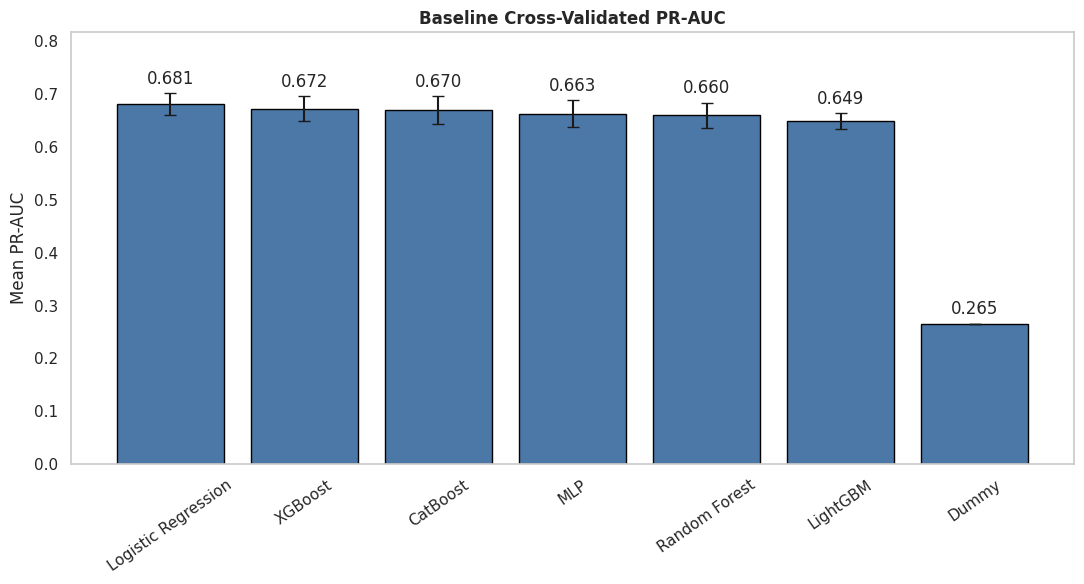

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    baseline_summary["Model"], baseline_summary["PR_AUC_Mean"],
    yerr=baseline_summary["PR_AUC_SD"], capsize=4,
    color="#4C78A8", edgecolor="black"
)
ax.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in baseline_summary["PR_AUC_Mean"]],
    padding=4
)
ax.set_title("Baseline Cross-Validated PR-AUC", fontweight="bold")
ax.set_ylabel("Mean PR-AUC")
ax.tick_params(axis="x", rotation=35)
ax.set_ylim(0, min(1.05, baseline_summary["PR_AUC_Mean"].max() * 1.20))
ax.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "08_baseline_cv_pr_auc.png")

In [ ]:
# Top three models eligible for a consistent class-weight comparison.
TOP_MODELS = (
    baseline_summary[
        baseline_summary["Model"].isin(BALANCE_ELIGIBLE_MODELS)
    ]
    .nlargest(3, "PR_AUC_Mean")["Model"]
    .tolist()
)

if len(TOP_MODELS) != 3:
    raise ValueError("Unable to select three balance-eligible models.")

print("Top three models for imbalance evaluation:", TOP_MODELS)

Top three models for imbalance evaluation: ['Logistic Regression', 'XGBoost', 'CatBoost']


### Candidate selection for imbalance experiments

Logistic regression, XGBoost, and CatBoost are the three strongest class-weight-compatible models by cross-validated PR-AUC. Restricting the more expensive imbalance analysis to these candidates reduces computation and multiple comparisons while retaining a linear model and two strong boosting models. The selection is based only on training-set cross-validation, not on the holdout test set.


## 7. Focused Class-Imbalance Evaluation


The original distribution is compared with two targeted alternatives: algorithm-level class weighting and SMOTE-NC oversampling to a 50:50 training distribution. This design answers the practical question of whether extra minority emphasis improves churn detection. Resampling occurs only within each cross-validation training fold, so synthetic records cannot leak into validation or test data. Although ratio-based balancing has been proposed in the churn literature [8], testing many arbitrary ratios would enlarge the search space and can discard or manufacture substantial information; the focused comparison is more proportionate to this dataset's moderate 2.77:1 imbalance.


In [ ]:
BALANCE_CHECKPOINT = OUTPUT_DIRS["results"] / "balance_cv_additional_fold_results.csv"

# Original rows are reused from Stage 1; only the two new conditions are fitted.
original_top_rows = baseline_cv_df[
    baseline_cv_df["Model"].isin(TOP_MODELS)
].copy()

additional_balance_rows = run_cv_jobs(
    model_names=TOP_MODELS,
    methods=["Class Weight", "SMOTE-NC 50:50"],
    checkpoint_path=BALANCE_CHECKPOINT,
)

balance_cv_df = pd.concat(
    [original_top_rows, additional_balance_rows], ignore_index=True
)
balance_summary = summarise_cv(balance_cv_df)

display(balance_summary)
balance_cv_df.to_csv(
    OUTPUT_DIRS["results"] / "balance_cv_all_fold_results.csv", index=False
)
balance_summary.to_csv(
    OUTPUT_DIRS["results"] / "balance_cv_summary.csv", index=False
)

Skipping saved result: Logistic Regression | Class Weight
Skipping saved result: XGBoost | Class Weight
Skipping saved result: CatBoost | Class Weight
Running: Logistic Regression | SMOTE-NC 50:50
Running: XGBoost | SMOTE-NC 50:50
Running: CatBoost | SMOTE-NC 50:50


,Model,Method,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,PR_AUC_SD,Accuracy_Mean,Balanced_Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,Brier_Mean,Train_PR_AUC_Mean,Fit_Time_Mean,Score_Time_Mean,PR-AUC Generalisation Gap
0,Logistic Regression,Original,0.8590,0.0140,0.6810,0.0212,0.8117,0.7336,0.6720,0.5672,0.6147,0.1300,0.6902,0.6901,0.1217,0.0092
1,Logistic Regression,Class Weight,0.8588,0.0137,0.6800,0.0202,0.7607,0.7780,0.5325,0.8147,0.6439,0.1581,0.6885,1.2140,0.3185,0.0085
2,Logistic Regression,SMOTE-NC 50:50,0.8549,0.0136,0.6747,0.0187,0.7787,0.7697,0.5625,0.7505,0.6428,0.1485,0.6839,2.7604,0.1329,0.0092
3,CatBoost,Class Weight,0.8572,0.0105,0.6738,0.0223,0.7755,0.7760,0.5552,0.7773,0.6475,0.1504,0.8406,2.3111,0.0874,0.1668
4,XGBoost,Original,0.8566,0.0123,0.6725,0.0240,0.8039,0.7221,0.6571,0.5478,0.5973,0.1328,0.8323,1.3270,0.1016,0.1598
5,XGBoost,Class Weight,0.8559,0.0115,0.6706,0.0252,0.7668,0.7703,0.5423,0.7779,0.6389,0.1525,0.8257,1.1676,0.0880,0.1551
6,CatBoost,Original,0.8573,0.0113,0.6701,0.0257,0.8048,0.7214,0.6616,0.5438,0.5967,0.1328,0.8675,2.2823,0.0906,0.1975
7,XGBoost,SMOTE-NC 50:50,0.8536,0.0143,0.6598,0.0221,0.8010,0.7573,0.6168,0.6642,0.6393,0.1394,0.7982,2.7732,0.0979,0.1384
8,CatBoost,SMOTE-NC 50:50,0.8516,0.0138,0.6580,0.0245,0.8000,0.7534,0.6159,0.6542,0.6342,0.1399,0.8247,4.0176,0.0754,0.1666


### Imbalance-treatment results

No treatment improves on logistic regression's original PR-AUC of **0.681**. Class weighting leaves its ranking performance nearly unchanged (**0.680**) but raises recall from **0.567** to **0.815**, while precision falls from **0.672** to **0.533** and the Brier score worsens from **0.130** to **0.158**. SMOTE-NC produces an intermediate operating point (recall **0.751**, precision **0.563**, PR-AUC **0.675**).

CatBoost benefits most in threshold-based terms from class weighting, reaching the highest mean F1 (**0.648**) among the treatment combinations and recall of **0.777**, with PR-AUC of **0.674**. XGBoost class weighting similarly raises recall to **0.778** but lowers precision to **0.542**. SMOTE-NC reduces PR-AUC for both boosting models. Thus, weighting and oversampling mainly change the precision–recall operating point rather than improving rank discrimination. The appropriate treatment depends on whether the campaign places greater cost on missed churners or on unnecessary retention offers.


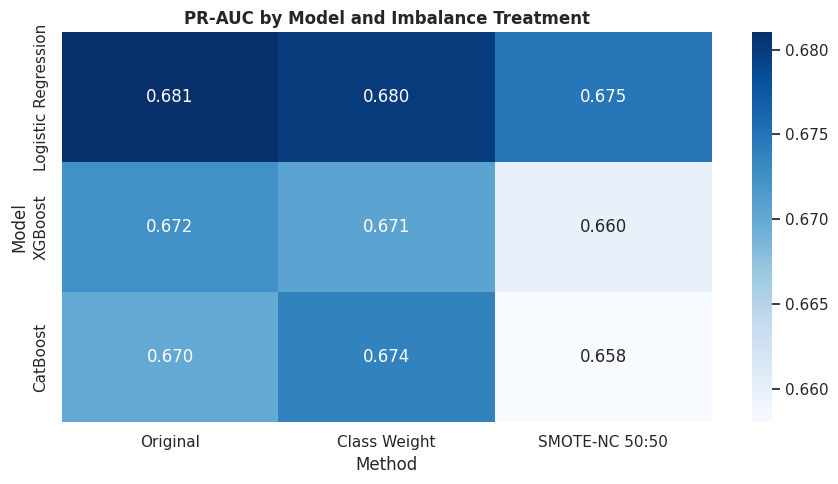

In [ ]:
method_order = ["Original", "Class Weight", "SMOTE-NC 50:50"]
heatmap_data = (
    balance_summary.pivot(index="Model", columns="Method", values="PR_AUC_Mean")
    .reindex(index=TOP_MODELS, columns=method_order)
)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="Blues")
plt.title("PR-AUC by Model and Imbalance Treatment", fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "09_balance_pr_auc_heatmap.png")

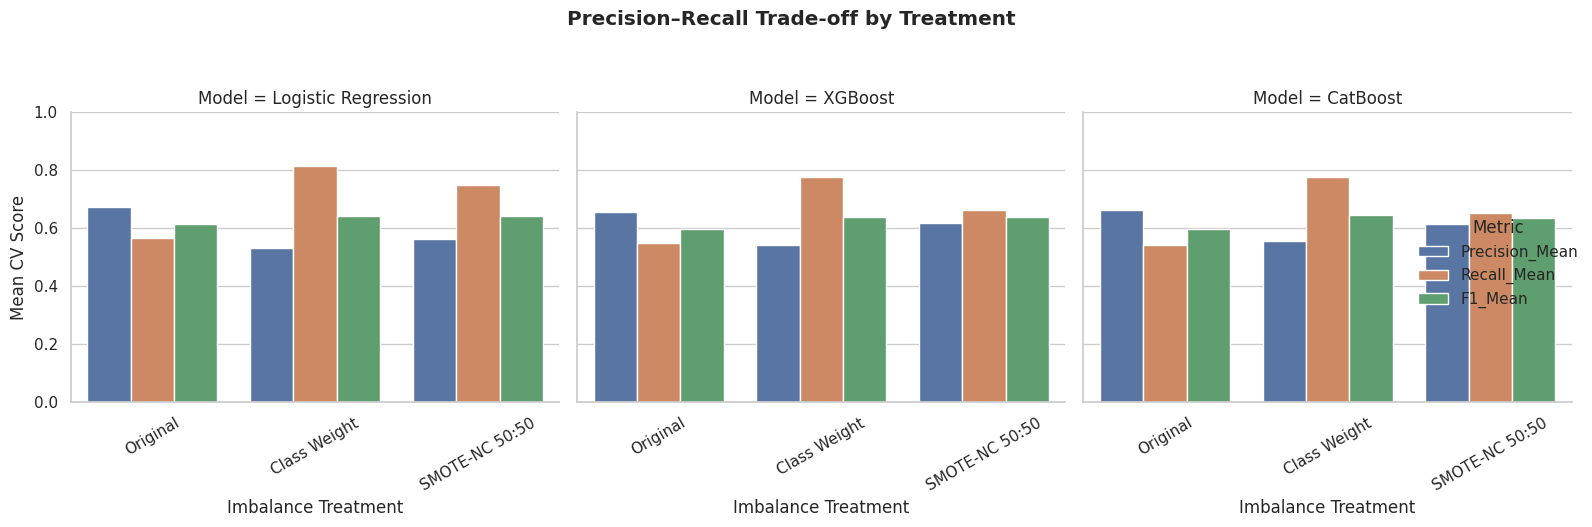

In [ ]:
# Precision–recall trade-off across imbalance treatments
balance_long = balance_summary.melt(
    id_vars=["Model", "Method"],
    value_vars=["Precision_Mean", "Recall_Mean", "F1_Mean"],
    var_name="Metric", value_name="Score"
)

g = sns.catplot(
    data=balance_long,
    x="Method", y="Score", hue="Metric", col="Model",
    kind="bar", height=5, aspect=0.95,
    col_order=TOP_MODELS, order=method_order
)
g.set_axis_labels("Imbalance Treatment", "Mean CV Score")
g.set_xticklabels(rotation=30)
g.set(ylim=(0, 1.0))
g.fig.suptitle("Precision–Recall Trade-off by Treatment", y=1.05, fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "10_balance_precision_recall_tradeoff.png")

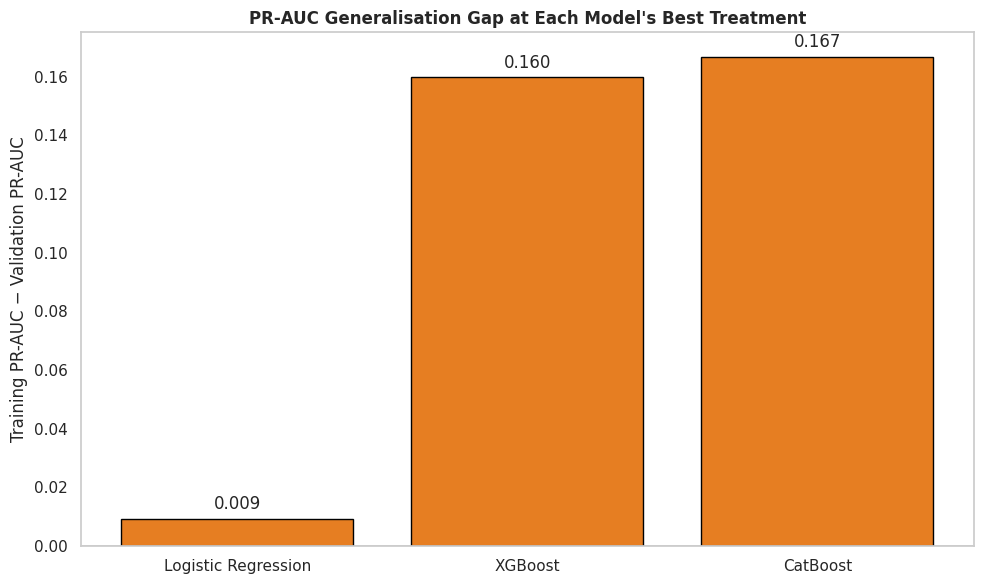

In [ ]:
best_balance_by_model = (
    balance_summary.sort_values("PR_AUC_Mean", ascending=False)
    .drop_duplicates("Model")
    .set_index("Model").loc[TOP_MODELS].reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    best_balance_by_model["Model"],
    best_balance_by_model["PR-AUC Generalisation Gap"],
    color="#E67E22", edgecolor="black"
)
ax.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in best_balance_by_model["PR-AUC Generalisation Gap"]],
    padding=4
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("PR-AUC Generalisation Gap at Each Model's Best Treatment", fontweight="bold")
ax.set_ylabel("Training PR-AUC − Validation PR-AUC")
ax.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "11_generalisation_gap.png")

### Generalisation assessment

At each model's best PR-AUC treatment, logistic regression retains a negligible training–validation gap (**0.009**), whereas XGBoost and class-weighted CatBoost retain gaps of approximately **0.160** and **0.167**. The boosting models therefore fit the training folds more strongly without delivering a corresponding validation improvement. This does not invalidate them, but it favours logistic regression when robustness, interpretability, and maintenance simplicity are important.


In [ ]:
test_rows = []
test_probabilities = {}
fitted_candidates = {}

for _, selection in best_balance_by_model.iterrows():
    model_name = selection["Model"]
    method = selection["Method"]
    print(f"Fitting {model_name} using CV-selected treatment: {method}")

    pipeline = build_pipeline(model_name, method)

    fit_start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    final_fit_time = time.perf_counter() - fit_start

    inference_start = time.perf_counter()
    probability = pipeline.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    inference_time = time.perf_counter() - inference_start

    safe_name = model_name.lower().replace(" ", "_")
    model_path = OUTPUT_DIRS["models"] / f"candidate_{safe_name}.joblib"
    # The fitted selector no longer needs its notebook-local scoring wrapper
    # for prediction. Replacing that reference makes the saved pipeline
    # easier to load in a separate deployment script.
    pipeline.named_steps["feature_selection"].score_func = mutual_info_classif
    joblib.dump(pipeline, model_path)

    fitted_candidates[model_name] = pipeline
    test_probabilities[model_name] = probability

    test_rows.append({
        "Model": model_name,
        "Selected Method": method,
        "CV PR-AUC": selection["PR_AUC_Mean"],
        "Test ROC-AUC": roc_auc_score(y_test, probability),
        "Test PR-AUC": average_precision_score(y_test, probability),
        "Test Accuracy": accuracy_score(y_test, prediction),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, prediction),
        "Test Precision": precision_score(y_test, prediction, zero_division=0),
        "Test Recall": recall_score(y_test, prediction, zero_division=0),
        "Test F1": f1_score(y_test, prediction, zero_division=0),
        "Test Brier": brier_score_loss(y_test, probability),
        "Final Fit Time (s)": final_fit_time,
        "Inference per Row (ms)": inference_time / len(X_test) * 1000,
        "Model Size (MB)": model_path.stat().st_size / (1024 ** 2),
    })

test_results_df = pd.DataFrame(test_rows).sort_values("CV PR-AUC", ascending=False)
display(test_results_df)
test_results_df.to_csv(
    OUTPUT_DIRS["results"] / "holdout_test_results.csv", index=False
)

prediction_output = pd.DataFrame({
    "CustomerID": df_model.loc[X_test.index, "CustomerID"],
    "Actual Churn": y_test,
})
for model_name, probability in test_probabilities.items():
    prediction_output[f"{model_name} Probability"] = probability
prediction_output.to_csv(
    OUTPUT_DIRS["results"] / "holdout_predictions.csv", index=False
)

Fitting Logistic Regression using CV-selected treatment: Original
Fitting XGBoost using CV-selected treatment: Original
Fitting CatBoost using CV-selected treatment: Class Weight


,Model,Selected Method,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Test Accuracy,Test Balanced Accuracy,Test Precision,Test Recall,Test F1,Test Brier,Final Fit Time (s),Inference per Row (ms),Model Size (MB)
0,Logistic Regression,Original,0.6810,0.8478,0.6474,0.8013,0.7213,0.6478,0.5508,0.5954,0.1361,2.3886,0.1065,0.0114
2,CatBoost,Class Weight,0.6738,0.8527,0.6671,0.7608,0.7612,0.5347,0.7620,0.6284,0.1537,9.6798,0.1177,0.3338
1,XGBoost,Original,0.6725,0.8523,0.6688,0.8027,0.7197,0.6548,0.5428,0.5936,0.1337,5.8314,0.1813,0.4510


### Holdout comparison

The untouched test set presents a nuanced result. XGBoost has the highest test PR-AUC (**0.669**) and lowest Brier score among the three candidates (**0.134**), with CatBoost close behind in PR-AUC (**0.667**). Class-weighted CatBoost provides the strongest threshold-based minority detection: recall **0.762**, balanced accuracy **0.761**, and F1 **0.628**, but its precision falls to **0.535**. Logistic regression achieves PR-AUC **0.647**, precision **0.648**, recall **0.551**, and a very small model size.

XGBoost's holdout advantage should be reported, but the test set should not be used to reverse a model choice made by the predeclared cross-validation procedure. Re-selecting after observing test performance would turn the test set into another validation set and produce an optimistic final estimate.


In [ ]:

champion_selection = balance_summary.iloc[0]
CHAMPION_NAME = champion_selection["Model"]
CHAMPION_METHOD = champion_selection["Method"]
champion_pipeline = fitted_candidates[CHAMPION_NAME]

CHAMPION_PATH = OUTPUT_DIRS["models"] / "champion_pipeline.joblib"
joblib.dump(champion_pipeline, CHAMPION_PATH)

champion_probability = test_probabilities[CHAMPION_NAME]
champion_prediction = (champion_probability >= 0.5).astype(int)

print("Champion:", CHAMPION_NAME)
print("Treatment:", CHAMPION_METHOD)
print(classification_report(
    y_test, champion_prediction,
    target_names=["Non-Churn", "Churn"], zero_division=0
))

Champion: Logistic Regression
Treatment: Original
              precision    recall  f1-score   support

   Non-Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Champion-model interpretation

Under the stated selection rule, the champion is **logistic regression trained on the original distribution** because it has the highest mean cross-validated PR-AUC. At the default 0.50 threshold, it correctly classifies 923 non-churners and 206 churners, while producing 112 false positives and 168 false negatives. Churn recall is **55%**, so approximately 45% of observed churners are missed at this threshold; churn precision is **65%**, meaning roughly two-thirds of flagged customers are true churners.

This operating point suits a campaign where unnecessary contact has a meaningful cost. If missed churners are more expensive, the class-weighted CatBoost result or a lower decision threshold may be preferable. Threshold choice is therefore a business-policy decision rather than a fixed property of the model.


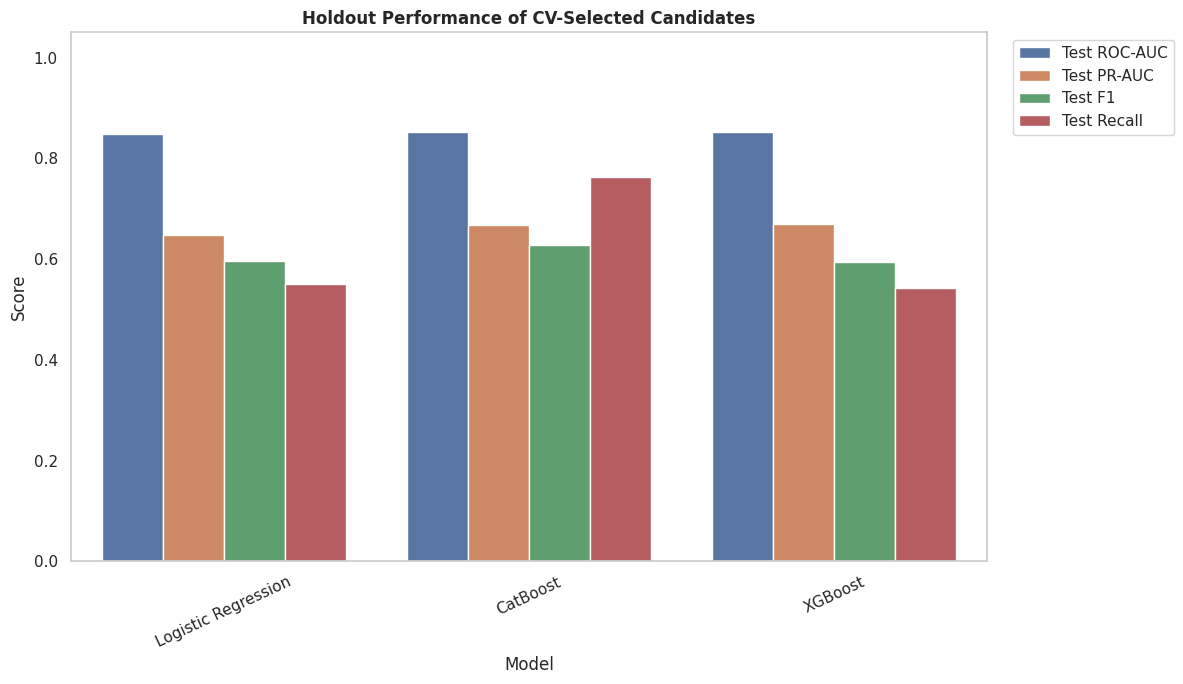

In [ ]:
# Holdout comparison bar chart
metric_cols = ["Test ROC-AUC", "Test PR-AUC", "Test F1", "Test Recall"]
long_test = test_results_df.melt(
    id_vars=["Model"], value_vars=metric_cols,
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=long_test, x="Model", y="Score", hue="Metric")
plt.title("Holdout Performance of CV-Selected Candidates", fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "12_holdout_model_comparison.png")

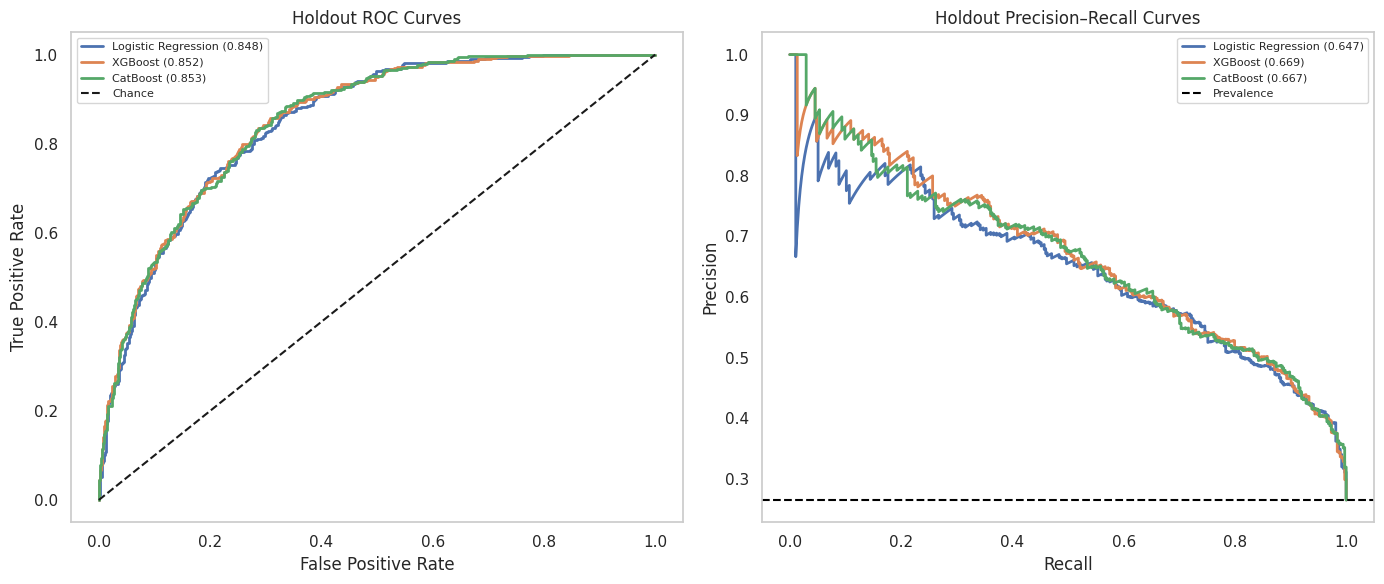

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model_name, probability in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    axes[0].plot(
        fpr, tpr, linewidth=2,
        label=f"{model_name} ({roc_auc_score(y_test, probability):.3f})"
    )

    precision, recall, _ = precision_recall_curve(y_test, probability)
    axes[1].plot(
        recall, precision, linewidth=2,
        label=f"{model_name} ({average_precision_score(y_test, probability):.3f})"
    )

axes[0].plot([0, 1], [0, 1], "k--", label="Chance")
axes[0].set_title("Holdout ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color="black", linestyle="--", label="Prevalence")
axes[1].set_title("Holdout Precision–Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(False)

save_and_show(OUTPUT_DIRS["figures"] / "13_holdout_roc_pr_curves.png")

### ROC and precision–recall curves

All three candidates show strong ROC discrimination (AUC approximately 0.85). The precision–recall curves are more informative for the minority class: each lies well above the 26.54% prevalence baseline, but differences among candidates are modest. XGBoost and CatBoost rank the holdout cases slightly better than logistic regression, whereas class-weighted CatBoost achieves higher recall at the 0.50 threshold. The full curves allow decision-makers to select a threshold that matches campaign capacity rather than relying exclusively on one summary score.


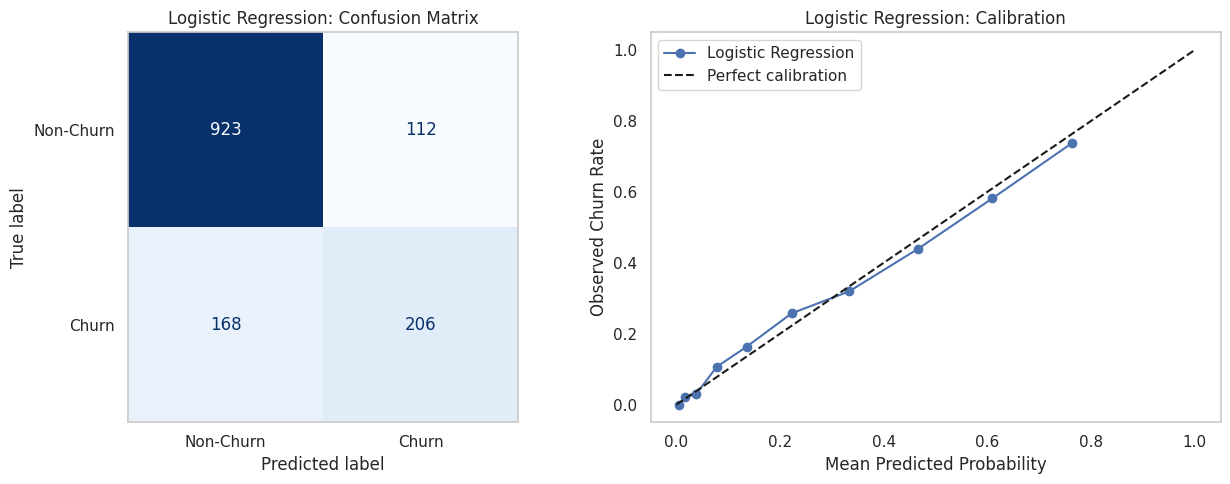

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, champion_prediction,
    display_labels=["Non-Churn", "Churn"],
    cmap="Blues", colorbar=False, ax=axes[0]
)
axes[0].set_title(f"{CHAMPION_NAME}: Confusion Matrix")

prob_true, prob_pred = calibration_curve(
    y_test, champion_probability, n_bins=10, strategy="quantile"
)
axes[1].plot(prob_pred, prob_true, marker="o", label=CHAMPION_NAME)
axes[1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Observed Churn Rate")
axes[1].set_title(f"{CHAMPION_NAME}: Calibration")
axes[1].legend()

for ax in axes:
    ax.grid(False)

save_and_show(OUTPUT_DIRS["figures"] / "14_champion_confusion_calibration.png")

### Confusion matrix and calibration

The champion's confusion matrix confirms its conservative churn classification: 206 of 374 churners are detected, while 112 of 1,035 non-churners receive false alerts. The calibration curve remains reasonably close to the diagonal across probability groups, consistent with the holdout Brier score of **0.136**, although modest departures remain at some bins. Because value-at-risk prioritisation multiplies probabilities by CLTV, probability calibration is operationally important; periodic recalibration should be considered if deployment data differ from this sample.


,Training N,Train PR-AUC Mean,Train PR-AUC SD,Validation PR-AUC Mean,Validation PR-AUC SD
0,563,0.7166,0.0062,0.6507,0.0103
1,1201,0.7065,0.0071,0.6721,0.0048
2,1840,0.6970,0.0037,0.6781,0.0109
3,2478,0.6902,0.0059,0.6742,0.0054
4,3117,0.6824,0.0094,0.6747,0.0108
5,3756,0.6857,0.0064,0.6734,0.0059


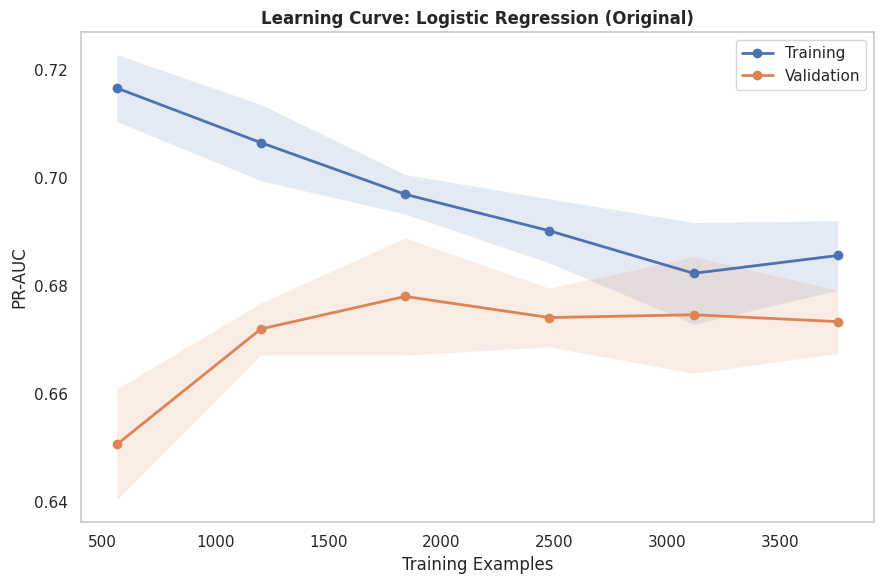

In [ ]:
learning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

train_sizes_abs, train_scores, validation_scores = learning_curve(
    build_pipeline(CHAMPION_NAME, CHAMPION_METHOD),
    X_train, y_train,
    train_sizes=np.linspace(0.15, 1.0, 6),
    cv=learning_cv,
    scoring="average_precision",
    n_jobs=1,
    shuffle=True,
    random_state=RANDOM_STATE,
)

learning_df = pd.DataFrame({
    "Training N": train_sizes_abs,
    "Train PR-AUC Mean": train_scores.mean(axis=1),
    "Train PR-AUC SD": train_scores.std(axis=1),
    "Validation PR-AUC Mean": validation_scores.mean(axis=1),
    "Validation PR-AUC SD": validation_scores.std(axis=1),
})
display(learning_df)
learning_df.to_csv(
    OUTPUT_DIRS["results"] / "champion_learning_curve.csv", index=False
)

plt.figure(figsize=(9, 6))
plt.plot(
    learning_df["Training N"], learning_df["Train PR-AUC Mean"],
    marker="o", linewidth=2, label="Training"
)
plt.fill_between(
    learning_df["Training N"],
    learning_df["Train PR-AUC Mean"] - learning_df["Train PR-AUC SD"],
    learning_df["Train PR-AUC Mean"] + learning_df["Train PR-AUC SD"],
    alpha=0.15
)
plt.plot(
    learning_df["Training N"], learning_df["Validation PR-AUC Mean"],
    marker="o", linewidth=2, label="Validation"
)
plt.fill_between(
    learning_df["Training N"],
    learning_df["Validation PR-AUC Mean"] - learning_df["Validation PR-AUC SD"],
    learning_df["Validation PR-AUC Mean"] + learning_df["Validation PR-AUC SD"],
    alpha=0.15
)
plt.title(f"Learning Curve: {CHAMPION_NAME} ({CHAMPION_METHOD})", fontweight="bold")
plt.xlabel("Training Examples")
plt.ylabel("PR-AUC")
plt.legend()
plt.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "15_champion_learning_curve.png")

### Learning-curve diagnosis

The training PR-AUC declines from **0.717** to **0.686** as the sample grows, while validation PR-AUC rises from **0.651** and stabilises around **0.67–0.68**. The gap contracts from approximately 0.066 to 0.012, providing little evidence of severe overfitting in the logistic model. Validation performance plateaus after roughly 1,200–1,800 training cases, suggesting that additional observations of the same structure may yield incremental rather than dramatic gains. Richer longitudinal usage, complaint, or interaction features may be more valuable than model complexity alone.


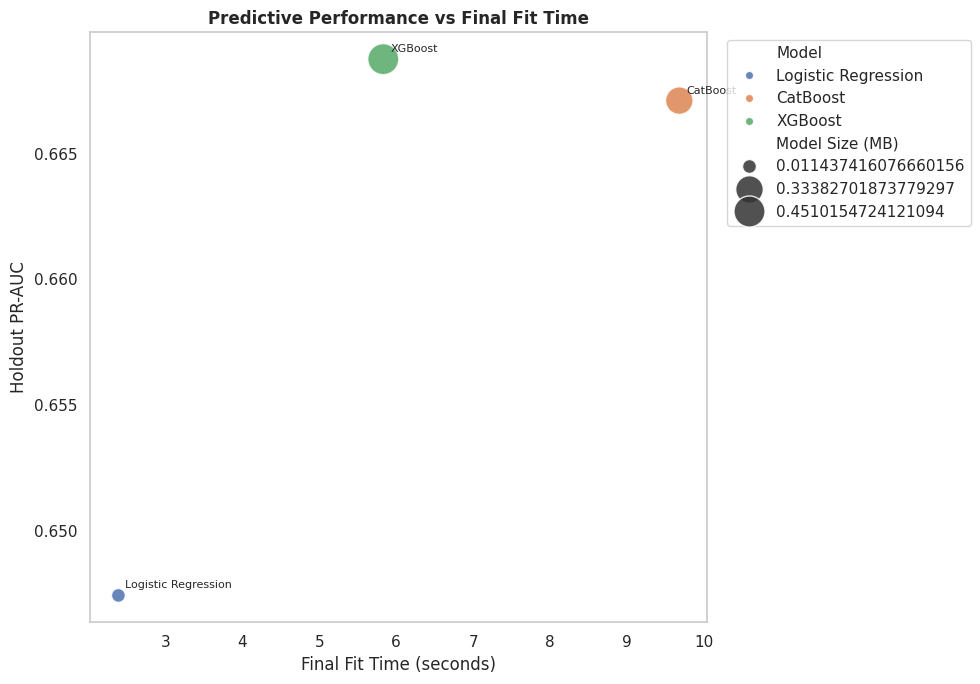

,Model,Selected Method,Test PR-AUC,Final Fit Time (s),Inference per Row (ms),Model Size (MB)
0,Logistic Regression,Original,0.6474,2.3886,0.1065,0.0114
2,CatBoost,Class Weight,0.6671,9.6798,0.1177,0.3338
1,XGBoost,Original,0.6688,5.8314,0.1813,0.4510


In [ ]:
tradeoff_df = test_results_df.copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tradeoff_df,
    x="Final Fit Time (s)", y="Test PR-AUC",
    hue="Model", size="Model Size (MB)", sizes=(100, 500), alpha=0.85
)
for _, row in tradeoff_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Final Fit Time (s)"], row["Test PR-AUC"]),
        xytext=(5, 5), textcoords="offset points", fontsize=8
    )
plt.title("Predictive Performance vs Final Fit Time", fontweight="bold")
plt.xlabel("Final Fit Time (seconds)")
plt.ylabel("Holdout PR-AUC")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "16_computational_tradeoff.png")

display(tradeoff_df[[
    "Model", "Selected Method", "Test PR-AUC", "Final Fit Time (s)",
    "Inference per Row (ms)", "Model Size (MB)"
]])

### Computational trade-off

Logistic regression requires **2.39 seconds** for the final fit and occupies only **0.011 MB**, compared with **5.83 seconds/0.451 MB** for XGBoost and **9.68 seconds/0.334 MB** for CatBoost in this run. XGBoost's holdout PR-AUC is 0.021 higher than logistic regression's, but the linear model is materially smaller, faster, more stable across folds, and easier to audit. All inference times are below 0.2 ms per row, so batch scoring is feasible for every candidate. Runtime is hardware-dependent; the defensible conclusion concerns relative trade-offs within this environment, not universal timings.


## 8. Explainability and Value-Aware Retention Prioritisation


In [ ]:
import shap

# Apply fitted preprocessing and feature selection without applying the training-only sampler.
X_test_imputed = champion_pipeline.named_steps["preprocess"].transform(X_test)
X_test_encoded = champion_pipeline.named_steps["postprocess"].transform(X_test_imputed)

all_feature_names = champion_pipeline.named_steps["postprocess"].get_feature_names_out()
selector = champion_pipeline.named_steps["feature_selection"]
selected_mask = selector.get_support()
selected_feature_names = np.asarray(all_feature_names)[selected_mask]
X_test_selected = selector.transform(X_test_encoded)

X_test_explain = pd.DataFrame(
    X_test_selected,
    columns=selected_feature_names,
    index=X_test.index,
)

feature_selection_df = pd.DataFrame({
    "Encoded Feature": all_feature_names,
    "Fold-Fitted MI Score": selector.scores_,
    "Selected": selected_mask,
}).sort_values("Fold-Fitted MI Score", ascending=False)

display(feature_selection_df.head(25))
feature_selection_df.to_csv(
    OUTPUT_DIRS["results"] / "champion_selected_features.csv", index=False
)

,Encoded Feature,Fold-Fitted MI Score,Selected
42,Contract_Month-to-month,0.0926,True
7,Monthly Charge per Service,0.0716,True
2,Tenure Months,0.0629,True
24,Online Security_No,0.0628,True
44,Contract_Two year,0.0605,True
33,Tech Support_No,0.0599,True
3,Monthly Charges,0.0494,True
22,Internet Service_Fiber optic,0.0493,True
51,Tenure Group_0–12,0.0470,True
49,Payment Method_Electronic check,0.0461,True


### Fold-fitted feature selection

Within the fitted champion pipeline, month-to-month contract, monthly charge per service, tenure, lack of online security, two-year contract, lack of technical support, monthly charges, fibre-optic service, early-tenure group, and electronic-check payment receive the largest mutual-information scores. These values are fitted on the training partition used by the final pipeline and are therefore more appropriate for documenting the selected model than the earlier full-data exploratory ranking. Mutual information ranks association but does not supply direction; directional interpretation is provided by SHAP.


PermutationExplainer explainer: 301it [00:32,  9.36it/s]                         


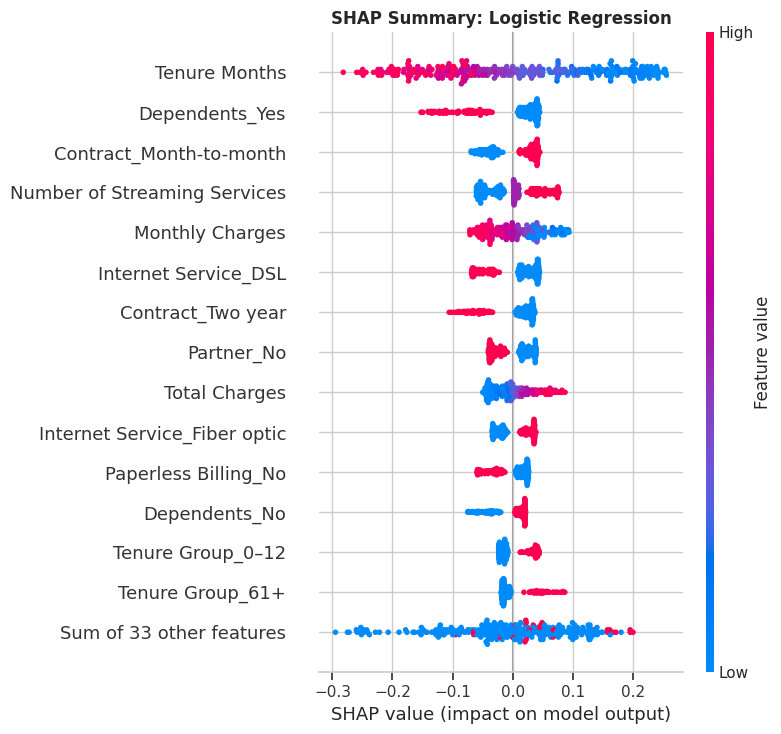

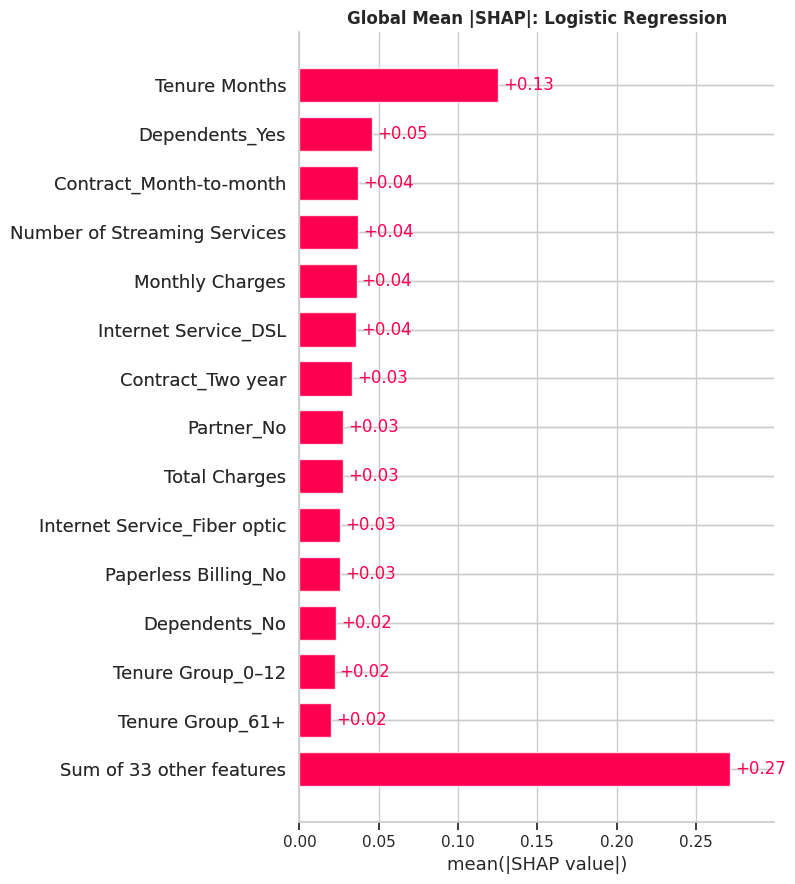

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


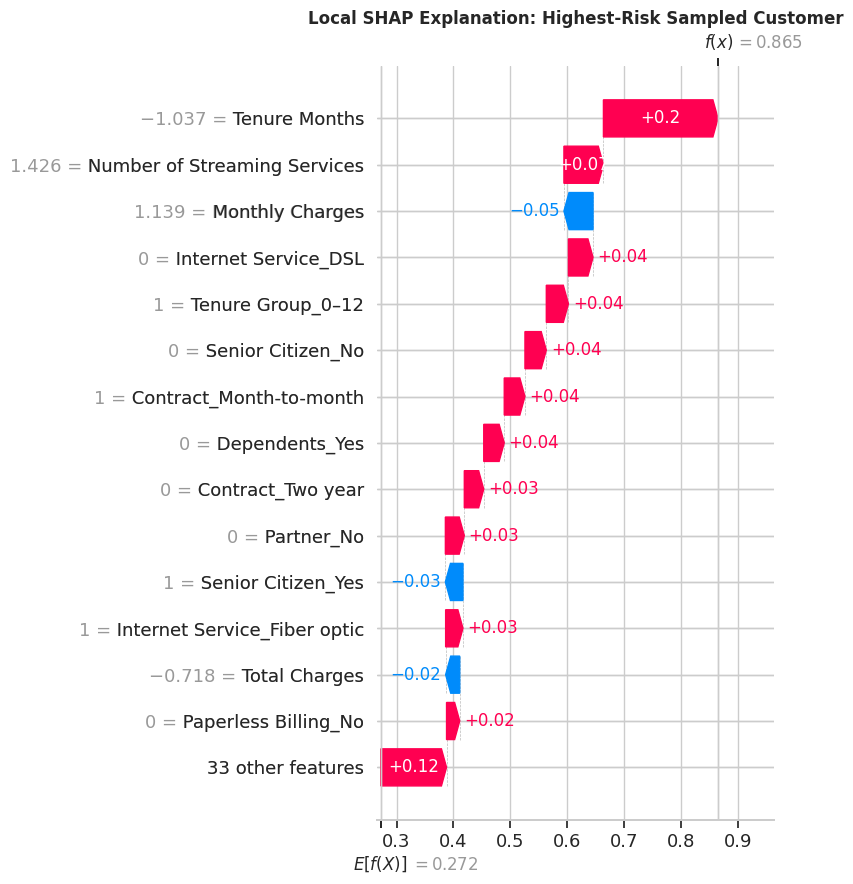

In [ ]:
SHAP_EXPLAIN_N = min(300, len(X_test_explain))
SHAP_BACKGROUND_N = min(75, len(X_test_explain))

X_shap = X_test_explain.sample(
    SHAP_EXPLAIN_N, random_state=RANDOM_STATE
)
champion_estimator = champion_pipeline.named_steps["model"]

TREE_MODELS = {"Random Forest", "XGBoost", "LightGBM", "CatBoost"}

if CHAMPION_NAME in TREE_MODELS:
    explainer = shap.TreeExplainer(champion_estimator)
    raw_shap = explainer(X_shap)
else:
    background = shap.sample(
        X_test_explain, SHAP_BACKGROUND_N, random_state=RANDOM_STATE
    )
    explainer = shap.Explainer(
        lambda z: champion_estimator.predict_proba(np.asarray(z))[:, 1],
        background,
        feature_names=selected_feature_names,
    )
    raw_shap = explainer(X_shap)


def positive_class_explanation(explanation):
    '''Normalize binary SHAP output to one Explanation for class 1.'''
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)

    if values.ndim == 3:
        values = values[:, :, 1]
        if base_values.ndim == 2:
            base_values = base_values[:, 1]
        elif base_values.ndim == 1 and len(base_values) == 2:
            base_values = np.repeat(base_values[1], values.shape[0])

    return shap.Explanation(
        values=values,
        base_values=base_values,
        data=X_shap.to_numpy(),
        feature_names=selected_feature_names,
    )


shap_values = positive_class_explanation(raw_shap)

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title(f"SHAP Summary: {CHAMPION_NAME}", fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "17_shap_beeswarm.png")

shap.plots.bar(shap_values, max_display=15, show=False)
plt.title(f"Global Mean |SHAP|: {CHAMPION_NAME}", fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "18_shap_global_bar.png")

sample_probabilities = champion_estimator.predict_proba(X_shap)[:, 1]
highest_risk_position = int(np.argmax(sample_probabilities))
shap.plots.waterfall(shap_values[highest_risk_position], max_display=15, show=False)
plt.title("Local SHAP Explanation: Highest-Risk Sampled Customer", fontweight="bold")
save_and_show(OUTPUT_DIRS["figures"] / "19_shap_high_risk_waterfall.png")

### SHAP discussion

Tenure is the dominant individual contributor to the logistic model, with global mean absolute SHAP importance of approximately **0.13**. Low tenure generally raises predicted churn probability, whereas high tenure lowers it. Having dependents, a two-year contract, and DSL service generally shift predictions toward lower churn; month-to-month contracts, early tenure, fibre-optic service, and the absence of protective relationship characteristics tend to shift predictions upward. The highest-risk sampled customer has a predicted probability of approximately **0.865**, driven most strongly by very low tenure, with month-to-month status and early-tenure membership adding further upward pressure.

Some conditional SHAP directions differ from univariate EDA—for example, charge variables share information with tenure, services, and contract. SHAP describes how the fitted model distributes prediction contributions in the presence of those dependencies; it is not a causal estimate. The bar labelled “Sum of 33 other features” is an aggregate of many small encoded effects and should not be interpreted as one dominant business variable.


In [ ]:
retention_df = pd.DataFrame({
    "CustomerID": df_model.loc[X_test.index, "CustomerID"],
    "Actual Churn": y_test,
    "Churn Probability": champion_probability,
    "CLTV": df_model.loc[X_test.index, "CLTV"],
}).reset_index(drop=True)

retention_df["Value at Risk"] = (
    retention_df["Churn Probability"] * retention_df["CLTV"]
)

# Thresholds are defined without using test outcomes.
risk_threshold = 0.50
high_value_threshold = df_model.loc[X_train.index, "CLTV"].median()

retention_df["Risk Level"] = np.where(
    retention_df["Churn Probability"] >= risk_threshold, "High Risk", "Low Risk"
)
retention_df["Value Level"] = np.where(
    retention_df["CLTV"] >= high_value_threshold, "High Value", "Low Value"
)

segment_map = {
    ("High Risk", "High Value"): "Priority Retention",
    ("High Risk", "Low Value"): "Efficient Retention",
    ("Low Risk", "High Value"): "Loyalty Monitoring",
    ("Low Risk", "Low Value"): "Standard Management",
}
retention_df["Retention Segment"] = [
    segment_map[(risk, value)]
    for risk, value in zip(retention_df["Risk Level"], retention_df["Value Level"])
]

retention_df["Priority Rank"] = (
    retention_df["Value at Risk"].rank(method="first", ascending=False).astype(int)
)
retention_df = retention_df.sort_values("Priority Rank")

display(retention_df.head(25))
retention_df.to_csv(
    OUTPUT_DIRS["results"] / "customer_retention_priorities.csv", index=False
)

,CustomerID,Actual Churn,Churn Probability,CLTV,Value at Risk,Risk Level,Value Level,Retention Segment,Priority Rank
1090,5178-LMXOP,1,0.8792,5795,"5,094.7196",High Risk,High Value,Priority Retention,1
1221,0295-PPHDO,1,0.8329,5962,"4,966.0069",High Risk,High Value,Priority Retention,2
1197,2865-TCHJW,1,0.7825,5808,"4,544.9830",High Risk,High Value,Priority Retention,3
234,7180-PISOG,1,0.8166,5554,"4,535.2098",High Risk,High Value,Priority Retention,4
952,1628-BIZYP,0,0.7858,5754,"4,521.5690",High Risk,High Value,Priority Retention,5
728,1320-HTRDR,1,0.7565,5948,"4,499.5628",High Risk,High Value,Priority Retention,6
1355,6630-UJZMY,0,0.8505,5251,"4,465.9440",High Risk,High Value,Priority Retention,7
647,6023-YEBUP,1,0.8296,5351,"4,438.9406",High Risk,High Value,Priority Retention,8
740,3716-BDVDB,1,0.7646,5795,"4,430.6564",High Risk,High Value,Priority Retention,9
1088,8361-LTMKD,1,0.7415,5839,"4,329.4533",High Risk,High Value,Priority Retention,10


### Value-aware prioritisation method

For each holdout customer, the notebook computes a prioritisation score:

$$\text{Value at Risk}_i = \widehat{P}(\text{churn}_i=1) \times \text{CLTV}_i.$$

A customer is classified as high risk when predicted probability is at least 0.50 and high value when CLTV is at least the training-set median. Using the training median avoids defining value groups from test outcomes. The score is a practical exposure proxy, not a complete expected-profit model: an operational campaign should also include contribution margin, intervention cost, offer acceptance probability, and the causal probability that an intervention prevents churn.


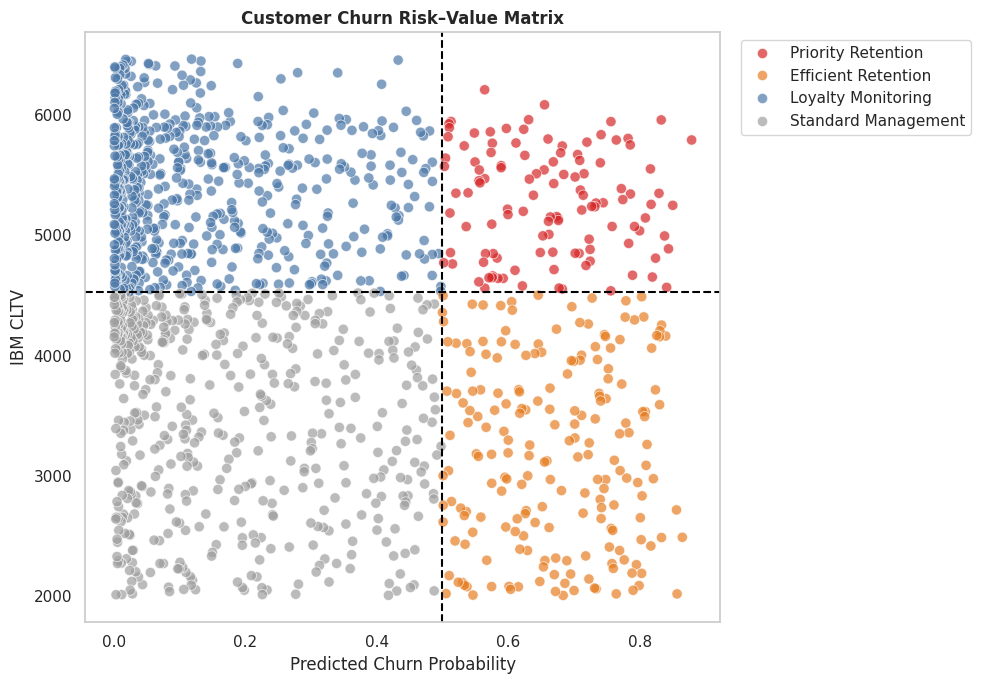

In [ ]:
segment_order = [
    "Priority Retention", "Efficient Retention",
    "Loyalty Monitoring", "Standard Management"
]
segment_palette = {
    "Priority Retention": "#D62728",
    "Efficient Retention": "#E67E22",
    "Loyalty Monitoring": "#4C78A8",
    "Standard Management": "#9E9E9E",
}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=retention_df,
    x="Churn Probability", y="CLTV",
    hue="Retention Segment", hue_order=segment_order,
    palette=segment_palette, alpha=0.70, s=55
)
plt.axvline(risk_threshold, color="black", linestyle="--")
plt.axhline(high_value_threshold, color="black", linestyle="--")
plt.title("Customer Churn Risk–Value Matrix", fontweight="bold")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("IBM CLTV")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "20_churn_risk_value_matrix.png")

,Retention Segment,Customers,Mean_Churn_Probability,Mean_CLTV,Total_Value_at_Risk
0,Priority Retention,116,0.6625,"5,278.4741","405,234.2324"
1,Efficient Retention,202,0.6697,"3,200.9158","432,986.8719"
2,Loyalty Monitoring,587,0.1301,"5,392.5434","409,164.3192"
3,Standard Management,504,0.1732,"3,480.6925","295,505.2253"


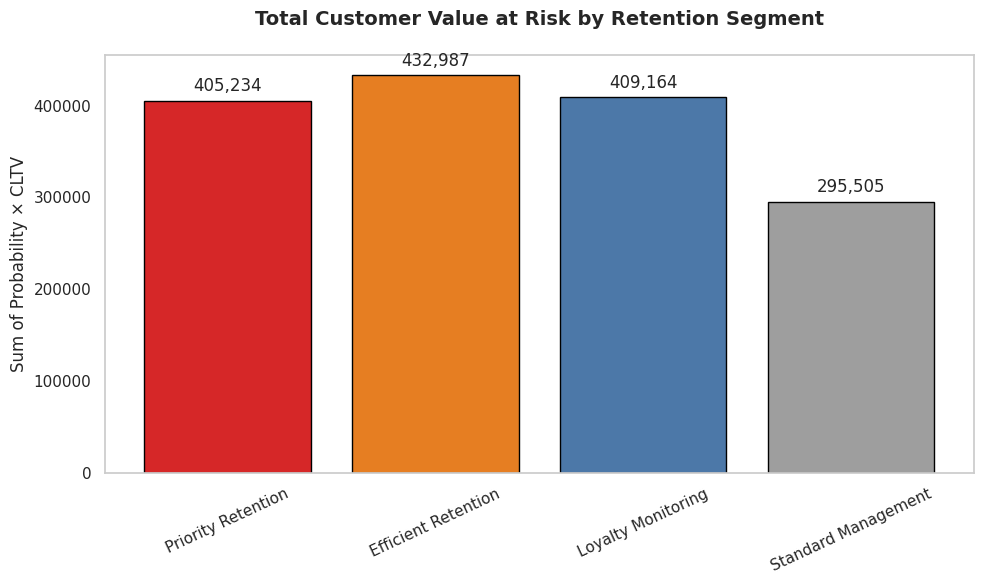

In [ ]:
segment_summary = (
    retention_df.groupby("Retention Segment", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        Mean_Churn_Probability=("Churn Probability", "mean"),
        Mean_CLTV=("CLTV", "mean"),
        Total_Value_at_Risk=("Value at Risk", "sum"),
    )
    .reindex(segment_order)
    .reset_index()
)
display(segment_summary)
segment_summary.to_csv(
    OUTPUT_DIRS["results"] / "retention_segment_summary.csv", index=False
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    segment_summary["Retention Segment"],
    segment_summary["Total_Value_at_Risk"],
    color=[segment_palette[s] for s in segment_summary["Retention Segment"]],
    edgecolor="black"
)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in segment_summary["Total_Value_at_Risk"]], padding=4)
ax.set_title("Total Customer Value at Risk by Retention Segment\n", fontweight="bold", fontsize=14)
ax.set_ylabel("Sum of Probability × CLTV")
ax.tick_params(axis="x", rotation=25)
ax.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "21_value_at_risk_by_segment.png")

### Retention-segment discussion

The **Priority Retention** segment contains 116 high-risk, high-value customers with mean predicted churn probability **0.663**, mean CLTV **5,278**, and aggregate value at risk of approximately **405,234**. These customers merit high-touch, personalised intervention. The **Efficient Retention** segment contains 202 high-risk, lower-value customers and has the largest aggregate exposure (**432,987**), supporting lower-cost scalable offers. **Loyalty Monitoring** includes 587 high-value but low-risk customers; its aggregate exposure remains sizeable because the group is large, but preventive service monitoring is more appropriate than aggressive discounts. The remaining 504 customers fall under **Standard Management**.

Aggregate exposure should not be confused with urgency at the individual level. The priority ranking is most defensible for ordering outreach within a fixed budget; it does not by itself prove that offering an incentive will be profitable or effective.


## 9. Exploratory Survival Analysis


### Survival-analysis purpose and caveat

Kaplan–Meier estimation is used to describe the probability of remaining with the provider across observed tenure, the log-rank test compares contract groups, and a penalised Cox proportional-hazards model estimates adjusted hazard ratios. Non-churners are treated as right-censored at their recorded tenure.

These results must remain **exploratory**. The IBM file is a synthetic cross-sectional snapshot and does not document cohort entry dates, censoring mechanisms, repeated observations, or time-varying covariates. Consequently, the analysis is useful for describing tenure-pattern differences but should not be presented as a validated longitudinal forecast or causal survival model.


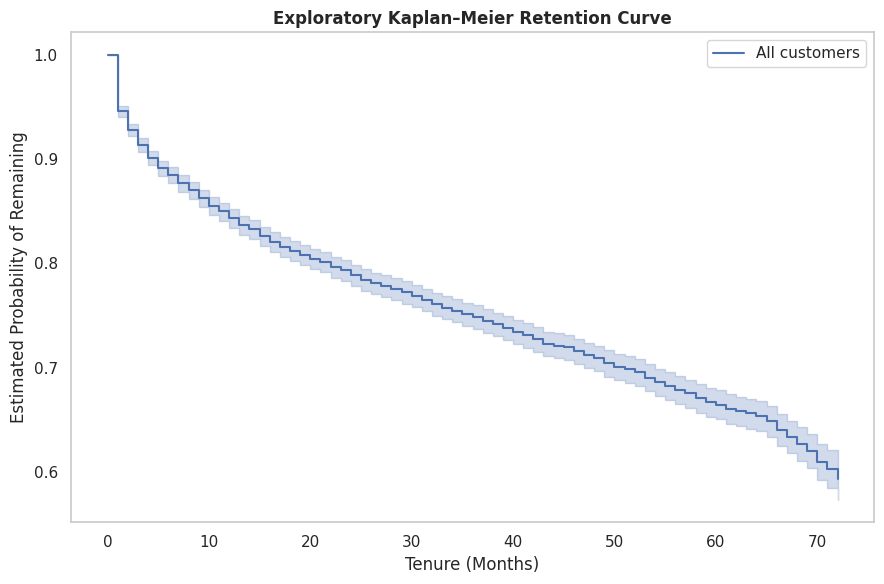

In [ ]:
# Overall Kaplan–Meier estimate
kmf = KaplanMeierFitter()
kmf.fit(
    durations=df_model["Tenure Months"],
    event_observed=df_model[TARGET_COL],
    label="All customers",
)

ax = kmf.plot_survival_function(figsize=(9, 6), ci_show=True)
ax.set_title("Exploratory Kaplan–Meier Retention Curve\n", fontweight="bold", fontsize=14
             )
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Estimated Probability of Remaining")
ax.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "22_kaplan_meier_overall.png")

kmf.survival_function_.to_csv(
    OUTPUT_DIRS["results"] / "kaplan_meier_overall.csv"
)

### Overall retention curve

The Kaplan–Meier estimate falls rapidly during the earliest tenure period and then declines more gradually, reaching approximately 0.59 by 72 months. This pattern is consistent with the classification and Mann–Whitney findings: churn is concentrated among customers with short tenure. The widening confidence interval near the end reflects fewer customers remaining under observation at long durations. Because the dataset is a snapshot, the curve should be interpreted as an empirical description of the recorded sample rather than a future survival probability for a newly acquired cohort.


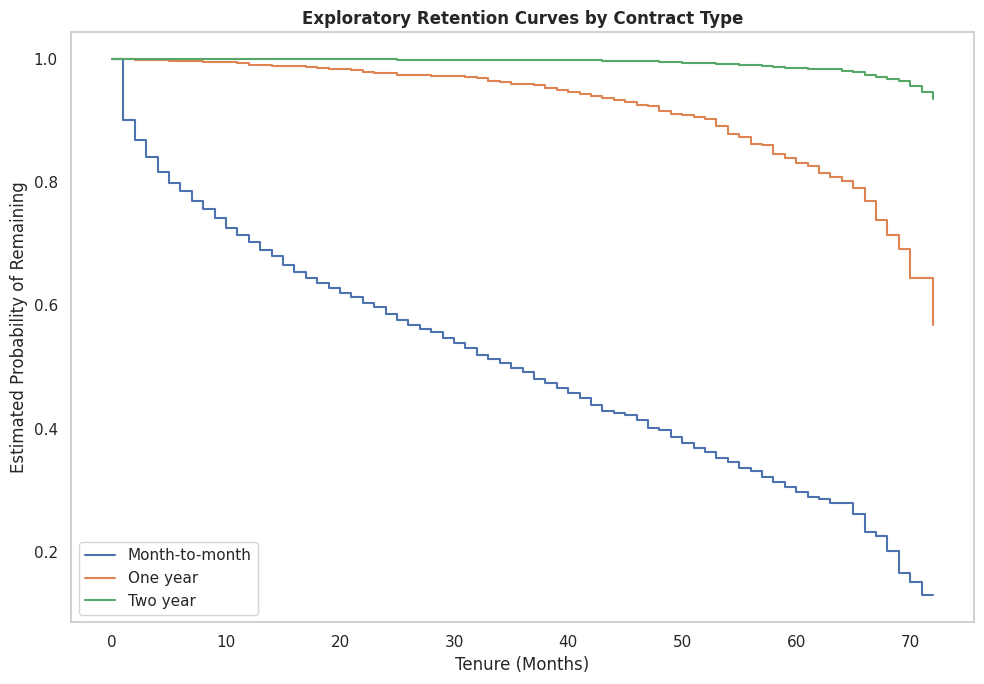

,Test Statistic,p-value
0,"2,352.8725",0.0000


In [ ]:
# Kaplan–Meier curves and a global log-rank test by contract type
fig, ax = plt.subplots(figsize=(10, 7))

for contract, subset in df_model.groupby("Contract", observed=True):
    km_contract = KaplanMeierFitter()
    km_contract.fit(
        subset["Tenure Months"],
        event_observed=subset[TARGET_COL],
        label=str(contract),
    )
    km_contract.plot_survival_function(ax=ax, ci_show=False)

ax.set_title("Exploratory Retention Curves by Contract Type", fontweight="bold")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Estimated Probability of Remaining")
ax.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "23_kaplan_meier_by_contract.png")

logrank_result = multivariate_logrank_test(
    event_durations=df_model["Tenure Months"],
    groups=df_model["Contract"],
    event_observed=df_model[TARGET_COL],
)

logrank_df = pd.DataFrame([{
    "Test Statistic": logrank_result.test_statistic,
    "p-value": logrank_result.p_value,
}])
display(logrank_df)
logrank_df.to_csv(OUTPUT_DIRS["results"] / "contract_logrank_test.csv", index=False)

### Retention by contract type

The contract curves are strongly separated. Month-to-month customers experience the steepest decline, one-year customers retain substantially better, and two-year customers remain highest throughout most of the observed tenure range. The global log-rank statistic is **2,352.87** with *p* < .001; the displayed value of 0.0000 reflects rounding, not a probability of exactly zero. The result supports rejection of equal retention functions across contract groups, but it does not establish that changing a customer's contract would itself cause the observed improvement.


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'Tenure Months'
                event col = 'Churn Value'
                penalizer = 0.05
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14548.62
         time fit was run = 2026-09-08 14:45:25 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Monthly Charges    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Senior Citizen     0.06      1.06      0.05           -0.04            0.16                0.96                1.18
Partner           -0.44      0.64      0.05           -0.53           -0.35                0.59                0.70
Dependents        -0.86      0.42      0.07           -1.00           -0.72                0.37                0.48
Contract_One year -1.44      0.24      0.06           -1.56           -1.32                0.21                0.27
Contract_Two year -2.19      0.11      0.07           -2.32           -2.05                0.10                0.13

                   cmp to      z      p  -log2(p)
covariate                                        
Monthly Charges      0.00   1.51   0.13      2.94
Senior Citizen       0.00   1.22   0.22      2.17
Partner              0.00  -9.69 <0.005     71.34
Dependents           0.00 -12.15 <0.005    110.37
Contract_One year    0.00 -23.21 <0.005    393.38
Contract_Two year    0.00 -30.77 <0.005    688.10
---
Concordance = 0.81
Partial AIC = 29109.24
log-likelihood ratio test = 2208.84 on 6 df
-log2(p) of ll-ratio test = inf

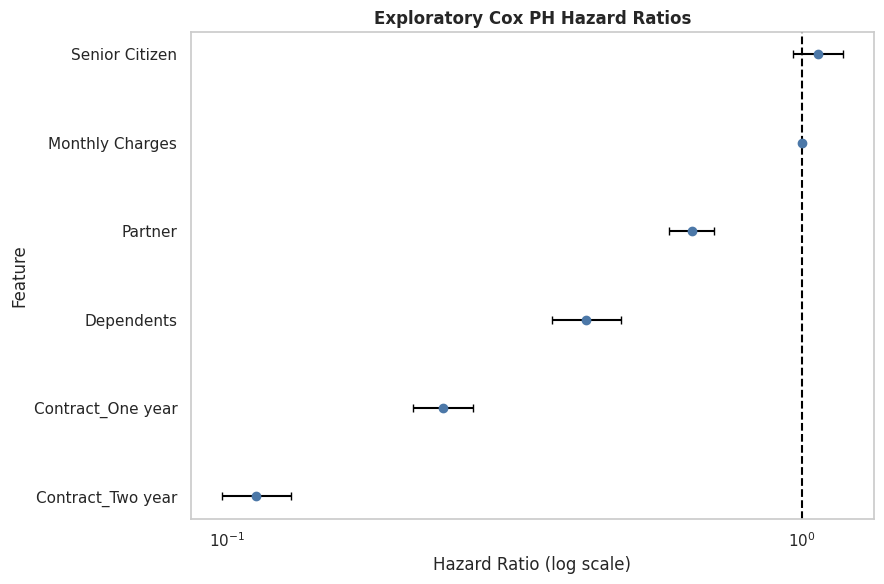

In [ ]:
# Penalized Cox proportional-hazards model using a small, interpretable feature set.
# Total Charges is excluded because it accumulates with the duration itself.
cox_df = df_model[[
    "Tenure Months", TARGET_COL, "Monthly Charges",
    "Senior Citizen", "Partner", "Dependents", "Contract"
]].copy()

for col in ["Senior Citizen", "Partner", "Dependents"]:
    cox_df[col] = cox_df[col].map({"No": 0, "Yes": 1})

cox_df = pd.get_dummies(cox_df, columns=["Contract"], drop_first=True, dtype=int)
cox_df = cox_df.dropna()

cph = CoxPHFitter(penalizer=0.05)
cph.fit(cox_df, duration_col="Tenure Months", event_col=TARGET_COL)
cph.print_summary()

cox_summary = cph.summary.copy()
cox_summary.to_csv(OUTPUT_DIRS["results"] / "cox_ph_summary.csv")

plot_df = cox_summary.sort_values("exp(coef)")
plt.figure(figsize=(9, 6))
plt.errorbar(
    plot_df["exp(coef)"],
    plot_df.index,
    xerr=[
        plot_df["exp(coef)"] - plot_df["exp(coef) lower 95%"],
        plot_df["exp(coef) upper 95%"] - plot_df["exp(coef)"],
    ],
    fmt="o", color="#4C78A8", ecolor="black", capsize=3
)
plt.axvline(1, color="black", linestyle="--")
plt.xscale("log")
plt.xlabel("Hazard Ratio (log scale)")
plt.ylabel("Feature")
plt.title("Exploratory Cox PH Hazard Ratios", fontweight="bold")
plt.grid(False)
save_and_show(OUTPUT_DIRS["figures"] / "24_cox_hazard_ratios.png")

### Cox proportional-hazards results

Month-to-month contract is the reference category. Holding the included covariates constant, the estimated churn hazard is approximately **76% lower** for one-year contracts (HR = **0.24**, 95% CI 0.21–0.27) and **89% lower** for two-year contracts (HR = **0.11**, 95% CI 0.10–0.13). Having dependents (HR = **0.42**) and a partner (HR = **0.64**) is also associated with lower observed hazard. Senior-citizen status (HR = **1.06**, *p* = .22) and monthly charges (HR ≈ **1.00**, *p* = .13) are not significant in this adjusted specification. Concordance is **0.81**, indicating strong ordering within the sample.

The Cox estimates are penalised and associational. Proportional-hazards diagnostics are not reported, and the cross-sectional construction limits time-to-event validity. Total charges are appropriately excluded because they accumulate with tenure and would mechanically encode the duration variable.


In [ ]:
manifest = {
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_splits": N_SPLITS,
    "fast_mode": FAST_MODE,
    "mi_percentile": MI_PERCENTILE,
    "dataset_path": str(DATA_PATH),
    "dataset_shape": list(raw_df.shape),
    "target_counts": {
        str(k): int(v) for k, v in df_model[TARGET_COL].value_counts().items()
    },
    "baseline_models": list(MODELS),
    "balance_top_models": TOP_MODELS,
    "balance_methods": ["Original", "Class Weight", "SMOTE-NC 50:50"],
    "champion_model": CHAMPION_NAME,
    "champion_method": CHAMPION_METHOD,
    "risk_threshold": risk_threshold,
    "high_value_threshold": float(high_value_threshold),
}

manifest_path = OUTPUT_DIRS["results"] / "reproducibility_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))

all_outputs = sorted(p for p in OUTPUT_ROOT.rglob("*") if p.is_file())
inventory_df = pd.DataFrame({
    "Artifact": [str(p.relative_to(PROJECT_DIR)) for p in all_outputs],
    "Size (KB)": [p.stat().st_size / 1024 for p in all_outputs],
})
display(inventory_df)
inventory_df.to_csv(
    OUTPUT_DIRS["results"] / "artifact_inventory.csv", index=False
)

,Artifact,Size (KB)
0,outputs/figures/01_target_distribution.png,184.5381
1,outputs/figures/02_numerical_distributiion.png,455.3174
2,outputs/figures/02_numerical_distributions.png,246.5234
3,outputs/figures/03_numerical_by_churn.png,605.9668
4,outputs/figures/04_categorical_distributions.png,930.5957
...,...,...
66,outputs/results/ratio_audit.csv,0.3809
67,outputs/results/reproducibility_manifest.json,0.8877
68,outputs/results/retention_segment_summary.csv,0.3887
69,outputs/results/spearman_correlation.csv,0.7803


## 10. Overall Discussion, Recommendations, and Conclusion

### 10.1 Answers to the research questions

- **RQ1:** Logistic regression is the predeclared champion, with the highest cross-validated PR-AUC (0.681), strong ROC-AUC (0.859), good calibration, and the smallest generalisation gap. XGBoost records the highest holdout PR-AUC (0.669), but this post-selection result is reported rather than used to reselect the model.
- **RQ2:** Class weighting substantially increases recall but reduces precision and worsens Brier scores. SMOTE-NC does not improve PR-AUC for the tested models. The original distribution is therefore preferred for the PR-AUC-selected champion, while class-weighted CatBoost is a credible alternative when missed churners are especially costly.
- **RQ3:** Contract, tenure, support/security services, internet type, payment method, and charge intensity provide the strongest signal. Gender, phone service, and geographic coordinates contribute little.
- **RQ4:** Multiplying calibrated churn probability by supplied CLTV produces a transparent prioritisation score and four operational segments. It is a decision-support heuristic rather than a causal profit estimate.
- **RQ5:** Exploratory survival results show markedly better observed retention for longer contracts. Cox estimates reinforce the association of contracts, dependents, and partner status with lower hazard, subject to the dataset's cross-sectional limitations.

### 10.2 Business recommendations

1. Prioritise the high-risk/high-value segment for personalised outreach and use lower-cost digital interventions for high-risk/lower-value customers.
2. Focus diagnostic attention on early-tenure, month-to-month, fibre-optic, electronic-check, and unsupported customers, while testing interventions rather than assuming these relationships are causal.
3. Select the classification threshold using campaign economics. A recall-oriented operation may favour class-weighted CatBoost or a lower logistic threshold; a capacity-constrained operation may prefer the original logistic model's higher precision.
4. Monitor probability calibration and data drift before using value-at-risk scores in production.
5. Validate retention offers through randomised or quasi-experimental testing and measure incremental retained value, not only classification accuracy.

### 10.3 Limitations

The dataset is synthetic, cross-sectional, geographically restricted, and relatively small. It lacks longitudinal usage, complaints, network quality, contact history, offer exposure, intervention cost, realised customer margin, and post-intervention outcomes. The supplied CLTV is treated as an external business value and is not independently validated. Hyperparameter search is deliberately limited, the 0.50 threshold is not profit-optimised, and only one holdout split is used. SHAP explains model behaviour rather than causal mechanisms. The survival analysis assumes right censoring and proportional hazards without sufficient temporal metadata to validate those assumptions.

### 10.4 Future work

Future research should use timestamped behavioural data, temporal validation, drift monitoring, nested hyperparameter optimisation, probability recalibration, and cost-sensitive threshold selection. A profit-based objective should incorporate expected margin, intervention cost, acceptance probability, and treatment effect. Uplift modelling or controlled experiments would help distinguish customers who are merely likely to churn from those whose churn can actually be prevented.

### 10.5 Conclusion

The study demonstrates that a comparatively simple logistic regression model can provide competitive churn ranking, stable generalisation, calibrated probabilities, compact deployment, and transparent explanations. More aggressive imbalance treatments improve churn recall but impose clear precision and calibration costs. The main contribution is therefore not a claim that one algorithm dominates universally, but an integrated framework that connects rigorous model comparison to explainable and value-aware retention decisions. The results identify short tenure and weak contractual commitment as the dominant risk pattern while showing that deployment choices must reflect business costs, customer value, and the limits of observational data.


## 11. References

1. Wagh, S. K., Andhale, A. A., Wagh, K. S., Pansare, J. R., Ambadekar, S. P., & Gawande, S. H. (2024). Customer churn prediction in telecom sector using machine learning techniques. *Results in Control and Optimization, 14*, 100342. https://doi.org/10.1016/j.rico.2023.100342
2. Imani, M., Joudaki, M., Beikmohammadi, A., & Arabnia, H. R. (2025). Customer churn prediction: A systematic review of recent advances, trends, and challenges in machine learning and deep learning. *Machine Learning and Knowledge Extraction, 7*(3), 105. https://doi.org/10.3390/make7030105
3. Liu, Y.-W., Wang, J., & Liu, C. (2025). Multimedia data-driven customer churn prediction using an enhanced extreme learning machine. *Scientific Reports, 15*, 38757. https://doi.org/10.1038/s41598-025-22564-4
4. Chang, V., Hall, K., Xu, Q. A., Amao, F. O., Ganatra, M. A., & Benson, V. (2024). Prediction of customer churn behavior in the telecommunication industry using machine learning models. *Algorithms, 17*(6), 231. https://doi.org/10.3390/a17060231
5. Poudel, S. S., Pokharel, S., & Timilsina, M. (2024). Explaining customer churn prediction in telecom industry using tabular machine learning models. *Machine Learning with Applications, 17*, 100567. https://doi.org/10.1016/j.mlwa.2024.100567
6. Manzoor, A., Qureshi, M. A., Kidney, E., & Longo, L. (2024). A review on machine learning methods for customer churn prediction and recommendations for business practitioners. *IEEE Access, 12*, 70434–70463. https://doi.org/10.1109/ACCESS.2024.3402092
7. Şahan, İ., Güner Şahan, P., Türkoğlu, F., Şahin, S., Aksoy, H., & Vayvalako, Y. (2025). A comparative analysis of machine learning models for customer churn prediction: A case study of Pronet Company. In *2025 33rd Signal Processing and Communications Applications Conference (SIU)*. https://doi.org/10.1109/SIU66497.2025.11111985
8. Sikri, A., Jameel, R., Idrees, S. M., & Kaur, H. (2024). Enhancing customer retention in telecom industry with machine learning driven churn prediction. *Scientific Reports, 14*, 13097. https://doi.org/10.1038/s41598-024-63750-0
